# Validation Plots (Editable)

This notebook is arranged so each figure has its own plotting cell.
The plotting code is expanded directly inside each figure cell instead of calling one shared plotting function.

Usage:
1. Run the setup cells first.
2. Open the figure cell you want.
3. Edit its local parameters at the top of that cell, such as `figsize`, `annotation_xy`, `x_limits`, `y_limits`, and legend positions.


In [1]:
import os
# 设置环境变量解决 OpenMP 冲突和内核崩溃
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
# 可选：设置线程数
os.environ['OMP_NUM_THREADS'] = '8'

import sys
from pathlib import Path
import importlib.util
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

def locate_project_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / "src" / "generate_validation_plots.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from the current notebook working directory.")


PROJECT_ROOT = locate_project_root()
SCRIPT_PATH = PROJECT_ROOT / "src" / "generate_validation_plots.py"

spec = importlib.util.spec_from_file_location("gvp", SCRIPT_PATH)
gvp = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(gvp)

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded helpers from: {SCRIPT_PATH}")

Project root: E:\JupyterProjects\RSM_WSGG
Loaded helpers from: E:\JupyterProjects\RSM_WSGG\src\generate_validation_plots.py


In [2]:
gvp.configure_publication_style()

SAVE_FIGURES = True
OUTPUT_DIR = PROJECT_ROOT / "results" / "img" / "publication_notebook"
PANEL_LABELS = False

COEFF_FILE = gvp.latest_coefficients_file(PROJECT_ROOT / "results")
WANG_FILE = PROJECT_ROOT / "input" / "coefficients_from_wang.xlsx"
SHEET_NAME = "Px=0.2bar"
PT = 1.0
X = 0.2
T_REF = 1000.0
BOUNDARY_TEMPERATURE = 300.0

CASE_FILES = sorted((PROJECT_ROOT / "input" / "profiles").glob("Case*.npy"), key=gvp.case_sort_key)
CASE_NAMES = [path.stem for path in CASE_FILES]

print(f"Coefficient file: {COEFF_FILE.name}")
print(f"Cases: {CASE_NAMES}")
print(f"Save figures: {SAVE_FIGURES}")

Coefficient file: coefficients_20260326_122927_Ng6_Exp4_Tref1000_bs16384.xlsx
Cases: ['Case1.1_L1.0m', 'Case1.2_L1.0m', 'Case1.3_L1.0m', 'Case2.1_L1.0m', 'Case2.2_L1.0m', 'Case3.1_L1.0m', 'Case3.2_L1.0m']
Save figures: True


In [3]:
beta, gamma = gvp.read_from_excel(str(COEFF_FILE))
beta = np.asarray(beta, dtype=float)
gamma = np.asarray(gamma, dtype=float)

main_mr, main_t, main_l, main_ref = gvp.load_emissivity_cube(gvp.DEFAULT_MAIN_DATASET)
main_rsm = gvp.predict_rsm_emissivity_cube(main_mr, main_t, main_l, beta, gamma, PT, X, T_REF)
main_wang = gvp.calculate_wang_emissivity_cube(WANG_FILE, SHEET_NAME, main_mr, main_t, main_l, PT)

val_mr, val_t, val_l, val_ref = gvp.load_emissivity_cube(gvp.DEFAULT_VALIDATION_DATASET)
val_rsm = gvp.predict_rsm_emissivity_cube(val_mr, val_t, val_l, beta, gamma, PT, X, T_REF)
val_wang = gvp.calculate_wang_emissivity_cube(WANG_FILE, SHEET_NAME, val_mr, val_t, val_l, PT)

print("Main dataset shape:", main_ref.shape)
print("Validation dataset shape:", val_ref.shape)

Main dataset shape: (40, 40, 40)
Validation dataset shape: (15, 22, 40)


In [4]:
def maybe_save(fig: plt.Figure, stem: str | None = None) -> None:
    fig.tight_layout()
    if SAVE_FIGURES and stem:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        png_path = OUTPUT_DIR / f"{stem}.png"
        pdf_path = OUTPUT_DIR / f"{stem}.pdf"
        fig.savefig(png_path, dpi=gvp.FIGURE_DPI, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")
        print(f"Saved {png_path}")
        print(f"Saved {pdf_path}")
    plt.show()


CASE_RESULTS = {}


def get_case_result(case_name: str, config_index: int):
    cache_key = (case_name, config_index)
    if cache_key in CASE_RESULTS:
        return CASE_RESULTS[cache_key]

    file_path = PROJECT_ROOT / "input" / "profiles" / f"{case_name}.npy"
    profile = np.load(file_path, allow_pickle=False)
    reference_results = np.load(PROJECT_ROOT / "results" / f"{case_name}.npy") / 1e3

    xs = profile["x"]
    length_value = float(case_name.split("_")[1][1:-1])
    x_rel = xs / length_value if length_value > 0 else xs
    temperature_profile = profile["T"]
    x_h2o = profile["Y_H2O"]
    x_nh3 = profile["Y_NH3"] + 1e-4

    wang_q, wang_dq = gvp.wsgg_wang_case_solution(xs, temperature_profile, x_h2o, x_nh3, WANG_FILE, SHEET_NAME, BOUNDARY_TEMPERATURE)
    rsm_q, rsm_dq = gvp.wsgg_rsm_case_solution(xs, temperature_profile, x_h2o, x_nh3, beta, gamma, T_REF, BOUNDARY_TEMPERATURE)

    wang_q = wang_q / 1e3
    wang_dq = wang_dq / 1e3
    rsm_q = rsm_q / 1e3
    rsm_dq = rsm_dq / 1e3

    reference_q = reference_results[:, 1]
    reference_st = -reference_results[:, 2]
    delta_q_rsm = gvp.relative_error_percent(reference_q, rsm_q)
    delta_q_wang = gvp.relative_error_percent(reference_q, wang_q)
    delta_st_rsm = gvp.relative_error_percent(reference_st, -rsm_dq)
    delta_st_wang = gvp.relative_error_percent(reference_st, -wang_dq)
    error_limit = gvp.rounded_error_limit(delta_q_rsm, delta_q_wang, delta_st_rsm, delta_st_wang)

    result = {
        "case_name": case_name,
        "config_index": config_index,
        "config_label": f"Cfg{config_index}",
        "length_value": length_value,
        "x_rel": x_rel,
        "reference_q": reference_q,
        "reference_st": reference_st,
        "wang_q": wang_q,
        "wang_st": -wang_dq,
        "rsm_q": rsm_q,
        "rsm_st": -rsm_dq,
        "delta_q_rsm": delta_q_rsm,
        "delta_q_wang": delta_q_wang,
        "delta_st_rsm": delta_st_rsm,
        "delta_st_wang": delta_st_wang,
        "error_limit": error_limit,
    }
    CASE_RESULTS[cache_key] = result
    return result


## Parity Plots


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\parity_rsm_kde.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\parity_rsm_kde.pdf


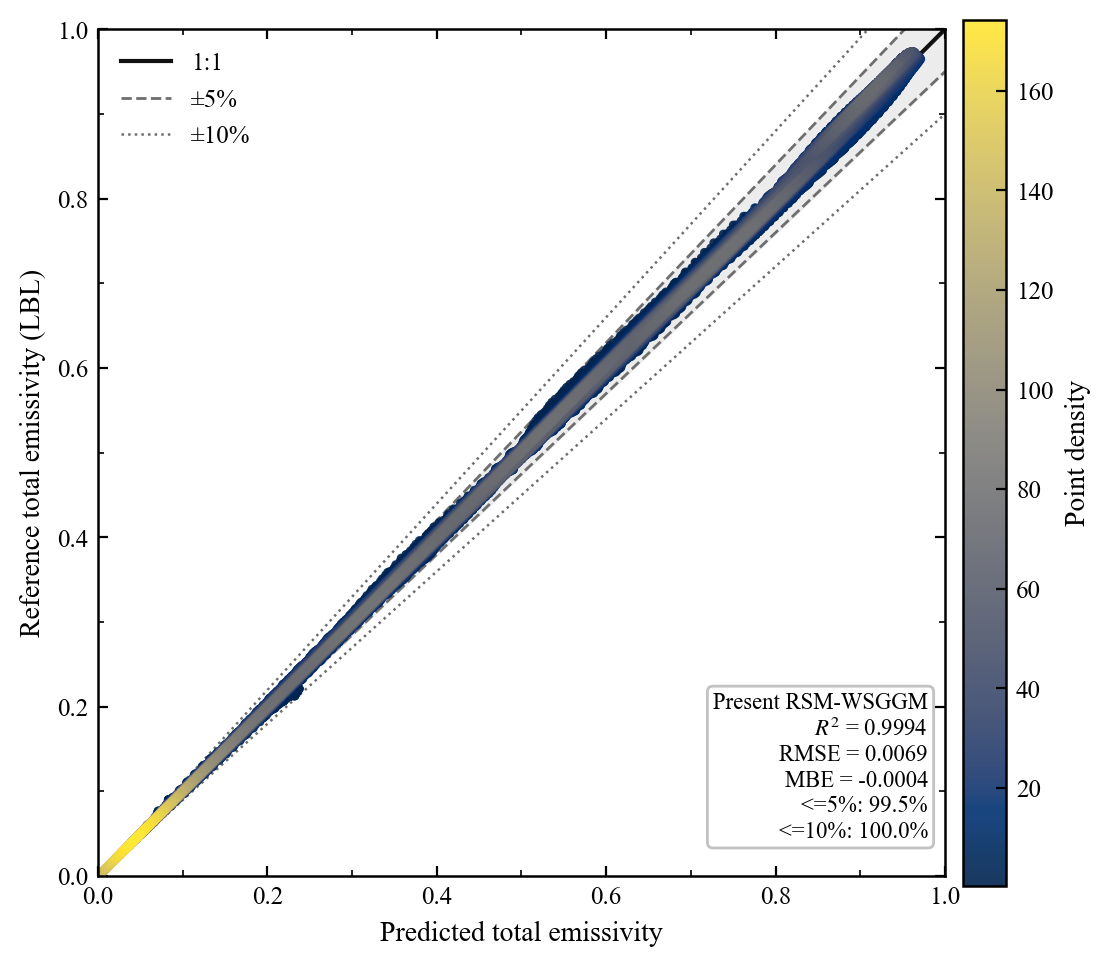

In [5]:
# Editable parameters for this figure
figsize = (5.5, 5.0)
x_limits = (0.0, 1.0)
y_limits = (0.0, 1.0)
stats_xy = (0.98, 0.04)
guide_legend_loc = "upper left"
save_stem = "parity_rsm_kde"

x = main_rsm.ravel()
y = main_ref.ravel()
xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)
order = np.argsort(density)

fig, ax = plt.subplots(figsize=figsize)
gvp.draw_parity_guides(ax, x_limits)

scatter = ax.scatter(
    x[order],
    y[order],
    c=density[order],
    cmap="cividis",
    s=10,
    linewidths=0.0,
    alpha=0.9,
    rasterized=True,
    zorder=2,
)
gvp.style_axes(ax)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted total emissivity")
ax.set_ylabel("Reference total emissivity (LBL)")
ax.legend(handles=gvp.parity_guide_handles(), loc=guide_legend_loc)
gvp.annotate_box(ax, gvp.stats_text("Present RSM-WSGGM", y, x), stats_xy, ha="right", va="bottom")
colorbar = fig.colorbar(scatter, ax=ax, fraction=0.05, pad=0.02)
colorbar.set_label("Point density")
colorbar.ax.tick_params(direction="in")
maybe_save(fig, save_stem if SAVE_FIGURES else None)

Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\parity_models_vs_lbl.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\parity_models_vs_lbl.pdf


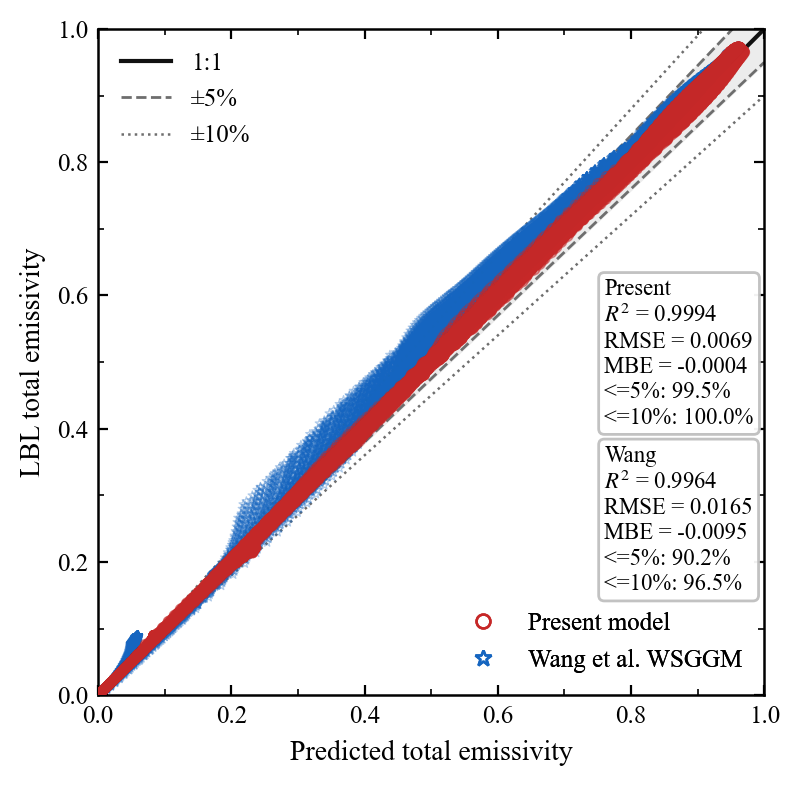

In [6]:
# Editable parameters for this figure
figsize = (4.5, 4.0)
x_limits = (0.0, 1.0)
y_limits = (0.0, 1.0)
guide_legend_loc = "upper left"
model_legend_loc = "lower right"
present_stats_xy = (0.76, 0.40)
wang_stats_xy = (0.76, 0.15)
save_stem = "parity_models_vs_lbl"

y = main_ref.ravel()
x_rsm = main_rsm.ravel()
x_wang = main_wang.ravel()

fig, ax = plt.subplots(figsize=figsize)
gvp.draw_parity_guides(ax, x_limits)
ax.scatter(
    x_wang,
    y,
    s=10,
    marker="*",
    facecolors="none",
    edgecolors=gvp.COLORS["wang"],
    linewidths=0.45,
    alpha=0.35,
    rasterized=True,
    zorder=2,
)
ax.scatter(
    x_rsm,
    y,
    s=10,
    marker="o",
    facecolors="none",
    edgecolors=gvp.COLORS["present"],
    linewidths=0.45,
    alpha=0.35,
    rasterized=True,
    zorder=3,
)
gvp.style_axes(ax)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted total emissivity")
ax.set_ylabel("LBL total emissivity")

guide_legend = ax.legend(handles=gvp.parity_guide_handles(), loc=guide_legend_loc)
model_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker="o",
        markerfacecolor="none",
        markeredgecolor=gvp.COLORS["present"],
        markeredgewidth=0.9,
        markersize=5.0,
        label="Present model",
    ),
    Line2D(
        [0], [0],
        linestyle="None",
        marker="*",
        markerfacecolor="none",
        markeredgecolor=gvp.COLORS["wang"],
        markeredgewidth=0.9,
        markersize=6.0,
        label="Wang et al. WSGGM",
    ),
]
model_legend = ax.legend(handles=model_handles, loc=model_legend_loc)
ax.add_artist(guide_legend)
ax.add_artist(model_legend)
gvp.annotate_box(ax, gvp.stats_text("Present", y, x_rsm), present_stats_xy, ha="left", va="bottom")
gvp.annotate_box(ax, gvp.stats_text("Wang", y, x_wang), wang_stats_xy, ha="left", va="bottom")

maybe_save(fig, save_stem if SAVE_FIGURES else None)


## Emissivity vs Temperature


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_temperature_mr_0p500.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_temperature_mr_0p500.pdf


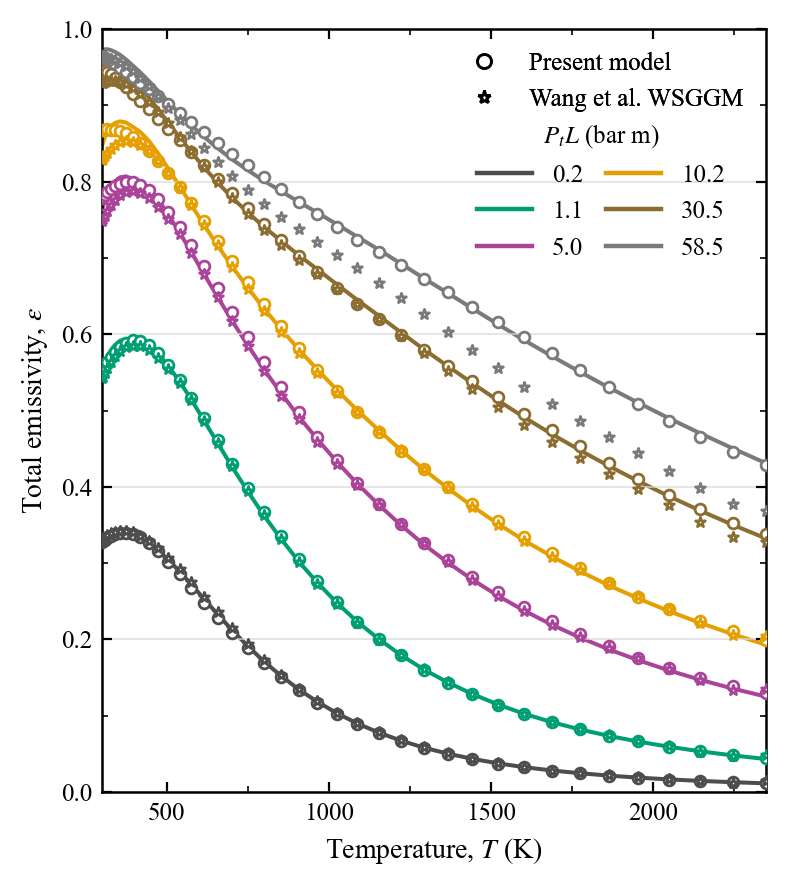

In [7]:
# Editable parameters for this figure
figsize = (4, 4.5)
selected_paths = [0.2, 1.0, 5.0, 10.0, 30.0, 60.0]
annotation_xy = (0.97, 0.96)
series_legend_loc = "upper left"
series_legend_anchor = (0.55, 0.89)
series_legend_ncol = 2
model_legend_loc = "upper right"
x_limits = None
y_limits = None
save_stem = "emissivity_vs_temperature_mr_0p500"

mr_value = 0.5
temperature_order = np.argsort(main_t)
path_order = np.argsort(main_l)
main_l_sorted = main_l[path_order]
mr_index = gvp.nearest_index(main_mr, mr_value)
selected_path_indices = [gvp.nearest_index(main_l_sorted, path) for path in selected_paths]

x_values = main_t[temperature_order]
reference_curves = [main_ref[mr_index, temperature_order, idx] for idx in selected_path_indices]
rsm_curves = [main_rsm[mr_index, temperature_order, idx] for idx in selected_path_indices]
wang_curves = [main_wang[mr_index, temperature_order, idx] for idx in selected_path_indices]
series_labels = ["{:.1f}".format(main_l_sorted[idx]) for idx in selected_path_indices]
annotation_text = "$M_r = {:.2f}$".format(mr_value)

if y_limits is None:
    y_limits = gvp.emissivity_ylim(reference_curves, rsm_curves, wang_curves)
if x_limits is None:
    x_limits = (float(x_values.min()), float(x_values.max()))

colors = gvp.choose_series_colors(len(series_labels))
fig, ax = plt.subplots(figsize=figsize)

for color, reference_curve, rsm_curve, wang_curve in zip(colors, reference_curves, rsm_curves, wang_curves):
    ax.plot(x_values, reference_curve, color=color, linewidth=1.45, zorder=1)
    ax.scatter(
        x_values,
        rsm_curve,
        marker="o",
        s=15,
        facecolors="white",
        edgecolors=color,
        linewidths=1.0,
        zorder=3,
    )
    ax.scatter(
        x_values,
        wang_curve,
        marker="*",
        s=14,
        facecolors="white",
        edgecolors=color,
        linewidths=0.95,
        zorder=3,
    )

gvp.style_axes(ax, grid_axis="y", logx=False)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_xlabel(r"Temperature, $T$ (K)")
ax.set_ylabel(r"Total emissivity, $\varepsilon$")
# gvp.annotate_box(ax, annotation_text, annotation_xy, ha="right")

series_handles = [
    Line2D([0], [0], color=color, linewidth=1.6, label=label)
    for color, label in zip(colors, series_labels)
]
legend_series = ax.legend(
    handles=series_handles,
    title=r"$P_tL$ (bar m)",
    loc=series_legend_loc,
    bbox_to_anchor=series_legend_anchor,
    borderaxespad=0.0,
    ncol=series_legend_ncol,
    columnspacing=0.9,
    handlelength=2.2,
)

model_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=5.0,
        label="Present model",
    ),
    Line2D(
        [0], [0],
        linestyle="None",
        marker="*",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=4.8,
        label="Wang et al. WSGGM",
    ),
]
legend_models = ax.legend(handles=model_handles, loc=model_legend_loc)

ax.add_artist(legend_series)
ax.add_artist(legend_models)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_temperature_mr_3p500.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_temperature_mr_3p500.pdf


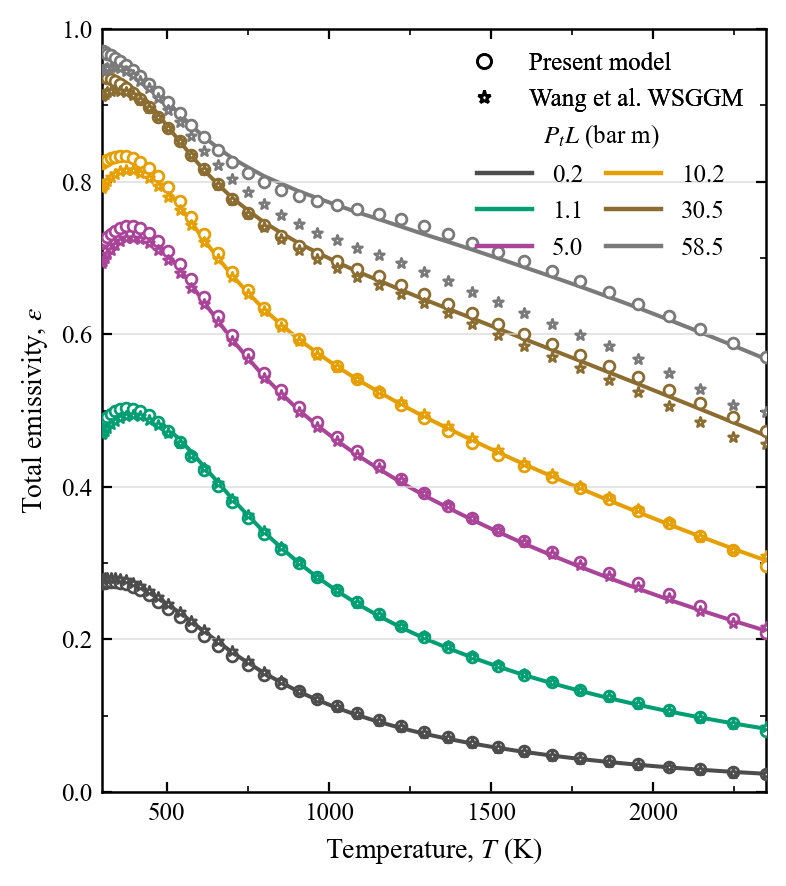

In [8]:
# Editable parameters for this figure
figsize = (4.0, 4.5)
selected_paths = [0.2, 1.0, 5.0, 10.0, 30.0, 60.0]
annotation_xy = (0.97, 0.96)
series_legend_loc = "upper left"
series_legend_anchor = (0.55, 0.89)
series_legend_ncol = 2
model_legend_loc = "upper right"
x_limits = None
y_limits = None
save_stem = "emissivity_vs_temperature_mr_3p500"

mr_value = 3.5
temperature_order = np.argsort(main_t)
path_order = np.argsort(main_l)
main_l_sorted = main_l[path_order]
mr_index = gvp.nearest_index(main_mr, mr_value)
selected_path_indices = [gvp.nearest_index(main_l_sorted, path) for path in selected_paths]

x_values = main_t[temperature_order]
reference_curves = [main_ref[mr_index, temperature_order, idx] for idx in selected_path_indices]
rsm_curves = [main_rsm[mr_index, temperature_order, idx] for idx in selected_path_indices]
wang_curves = [main_wang[mr_index, temperature_order, idx] for idx in selected_path_indices]
series_labels = ["{:.1f}".format(main_l_sorted[idx]) for idx in selected_path_indices]
annotation_text = "$M_r = {:.2f}$".format(mr_value)

if y_limits is None:
    y_limits = gvp.emissivity_ylim(reference_curves, rsm_curves, wang_curves)
if x_limits is None:
    x_limits = (float(x_values.min()), float(x_values.max()))

colors = gvp.choose_series_colors(len(series_labels))
fig, ax = plt.subplots(figsize=figsize)

for color, reference_curve, rsm_curve, wang_curve in zip(colors, reference_curves, rsm_curves, wang_curves):
    ax.plot(x_values, reference_curve, color=color, linewidth=1.45, zorder=1)
    ax.scatter(
        x_values,
        rsm_curve,
        marker="o",
        s=15,
        facecolors="white",
        edgecolors=color,
        linewidths=1.0,
        zorder=3,
    )
    ax.scatter(
        x_values,
        wang_curve,
        marker="*",
        s=14,
        facecolors="white",
        edgecolors=color,
        linewidths=0.95,
        zorder=3,
    )

gvp.style_axes(ax, grid_axis="y", logx=False)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_xlabel(r"Temperature, $T$ (K)")
ax.set_ylabel(r"Total emissivity, $\varepsilon$")
# gvp.annotate_box(ax, annotation_text, annotation_xy, ha="right")

series_handles = [
    Line2D([0], [0], color=color, linewidth=1.6, label=label)
    for color, label in zip(colors, series_labels)
]
legend_series = ax.legend(
    handles=series_handles,
    title=r"$P_tL$ (bar m)",
    loc=series_legend_loc,
    bbox_to_anchor=series_legend_anchor,
    borderaxespad=0.0,
    ncol=series_legend_ncol,
    columnspacing=0.9,
    handlelength=2.2,
)

model_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=5.0,
        label="Present model",
    ),
    Line2D(
        [0], [0],
        linestyle="None",
        marker="*",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=4.8,
        label="Wang et al. WSGGM",
    ),
]
legend_models = ax.legend(handles=model_handles, loc=model_legend_loc)

ax.add_artist(legend_series)
ax.add_artist(legend_models)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


## Emissivity vs Path Length (Fixed Mole Ratio)


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_mr_0p500.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_mr_0p500.pdf


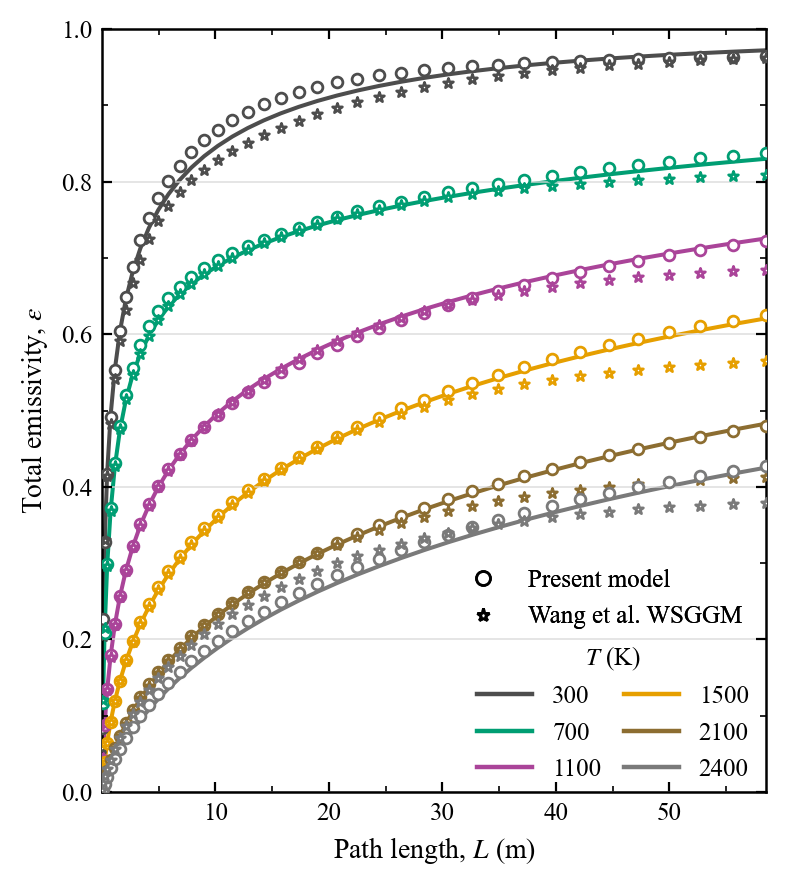

In [9]:
# Editable parameters for this figure
figsize = (4.0, 4.5)
selected_temperatures = [300.0, 700.0, 1100.0, 1500.0, 2100.0, 2400.0]
annotation_xy = (0.97, 0.96)
series_legend_loc = "lower left"
series_legend_anchor = (0.55, 0.0)
series_legend_ncol = 2
model_legend_loc = "lower right"
model_legend_anchor = (0.98, 0.2)
x_limits = None
y_limits = None
save_stem = "emissivity_vs_path_length_mr_0p500"

mr_value = 0.5
path_order = np.argsort(val_l)
val_l_sorted = val_l[path_order]
mr_index = gvp.nearest_index(val_mr, mr_value)
selected_temperature_indices = [gvp.nearest_index(val_t, temperature) for temperature in selected_temperatures]

x_values = val_l_sorted
reference_curves = [val_ref[mr_index, idx, :][path_order] for idx in selected_temperature_indices]
rsm_curves = [val_rsm[mr_index, idx, :][path_order] for idx in selected_temperature_indices]
wang_curves = [val_wang[mr_index, idx, :][path_order] for idx in selected_temperature_indices]
series_labels = ["{:.0f}".format(val_t[idx]) for idx in selected_temperature_indices]
annotation_text = "$M_r = {:.2f}$".format(mr_value)

if y_limits is None:
    y_limits = gvp.emissivity_ylim(reference_curves, rsm_curves, wang_curves)
if x_limits is None:
    x_limits = (float(x_values.min()), float(x_values.max()))

colors = gvp.choose_series_colors(len(series_labels))
fig, ax = plt.subplots(figsize=figsize)

for color, reference_curve, rsm_curve, wang_curve in zip(colors, reference_curves, rsm_curves, wang_curves):
    ax.plot(x_values, reference_curve, color=color, linewidth=1.45, zorder=1)
    ax.scatter(
        x_values,
        rsm_curve,
        marker="o",
        s=15,
        facecolors="white",
        edgecolors=color,
        linewidths=1.0,
        zorder=3,
    )
    ax.scatter(
        x_values,
        wang_curve,
        marker="*",
        s=14,
        facecolors="white",
        edgecolors=color,
        linewidths=0.95,
        zorder=3,
    )

gvp.style_axes(ax, grid_axis="y", logx=False)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_xlabel(r"Path length, $L$ (m)")
ax.set_ylabel(r"Total emissivity, $\varepsilon$")
# gvp.annotate_box(ax, annotation_text, annotation_xy, ha="right")

series_handles = [
    Line2D([0], [0], color=color, linewidth=1.6, label=label)
    for color, label in zip(colors, series_labels)
]
legend_series = ax.legend(
    handles=series_handles,
    title=r"$T$ (K)",
    loc=series_legend_loc,
    bbox_to_anchor=series_legend_anchor,
    borderaxespad=0.0,
    ncol=series_legend_ncol,
    columnspacing=0.9,
    handlelength=2.2,
)

model_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=5.0,
        label="Present model",
    ),
    Line2D(
        [0], [0],
        linestyle="None",
        marker="*",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=4.8,
        label="Wang et al. WSGGM",
    ),
]
legend_models = ax.legend(
    handles=model_handles,
    loc=model_legend_loc,
    bbox_to_anchor=model_legend_anchor,
    borderaxespad=0.0,
)

ax.add_artist(legend_series)
ax.add_artist(legend_models)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_mr_3p500.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_mr_3p500.pdf


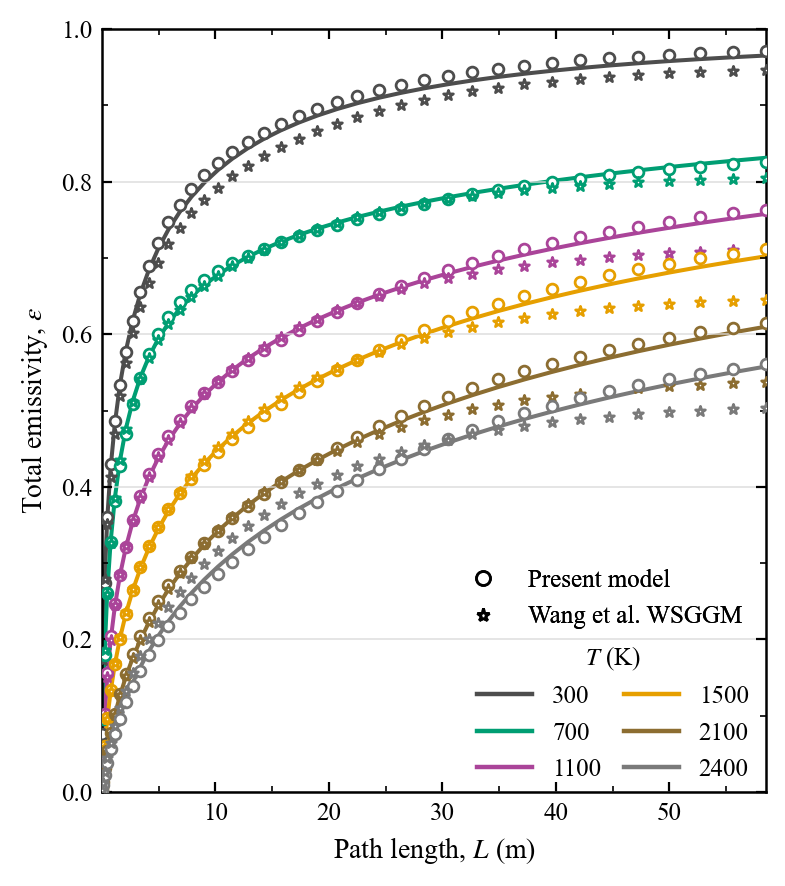

In [10]:
# Editable parameters for this figure
figsize = (4.0, 4.5)
selected_temperatures = [300.0, 700.0, 1100.0, 1500.0, 2100.0, 2400.0]
annotation_xy = (0.97, 0.96)
series_legend_loc = "lower left"
series_legend_anchor = (0.55, 0.0)
series_legend_ncol = 2
model_legend_loc = "lower right"
model_legend_anchor = (0.98, 0.2)
x_limits = None
y_limits = None
save_stem = "emissivity_vs_path_length_mr_3p500"

mr_value = 3.5
path_order = np.argsort(val_l)
val_l_sorted = val_l[path_order]
mr_index = gvp.nearest_index(val_mr, mr_value)
selected_temperature_indices = [gvp.nearest_index(val_t, temperature) for temperature in selected_temperatures]

x_values = val_l_sorted
reference_curves = [val_ref[mr_index, idx, :][path_order] for idx in selected_temperature_indices]
rsm_curves = [val_rsm[mr_index, idx, :][path_order] for idx in selected_temperature_indices]
wang_curves = [val_wang[mr_index, idx, :][path_order] for idx in selected_temperature_indices]
series_labels = ["{:.0f}".format(val_t[idx]) for idx in selected_temperature_indices]
annotation_text = "$M_r = {:.2f}$".format(mr_value)

if y_limits is None:
    y_limits = gvp.emissivity_ylim(reference_curves, rsm_curves, wang_curves)
if x_limits is None:
    x_limits = (float(x_values.min()), float(x_values.max()))

colors = gvp.choose_series_colors(len(series_labels))
fig, ax = plt.subplots(figsize=figsize)

for color, reference_curve, rsm_curve, wang_curve in zip(colors, reference_curves, rsm_curves, wang_curves):
    ax.plot(x_values, reference_curve, color=color, linewidth=1.45, zorder=1)
    ax.scatter(
        x_values,
        rsm_curve,
        marker="o",
        s=15,
        facecolors="white",
        edgecolors=color,
        linewidths=1.0,
        zorder=3,
    )
    ax.scatter(
        x_values,
        wang_curve,
        marker="*",
        s=14,
        facecolors="white",
        edgecolors=color,
        linewidths=0.95,
        zorder=3,
    )

gvp.style_axes(ax, grid_axis="y", logx=False)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_xlabel(r"Path length, $L$ (m)")
ax.set_ylabel(r"Total emissivity, $\varepsilon$")
# gvp.annotate_box(ax, annotation_text, annotation_xy, ha="right")

series_handles = [
    Line2D([0], [0], color=color, linewidth=1.6, label=label)
    for color, label in zip(colors, series_labels)
]
legend_series = ax.legend(
    handles=series_handles,
    title=r"$T$ (K)",
    loc=series_legend_loc,
    bbox_to_anchor=series_legend_anchor,
    borderaxespad=0.0,
    ncol=series_legend_ncol,
    columnspacing=0.9,
    handlelength=2.2,
)

model_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=5.0,
        label="Present model",
    ),
    Line2D(
        [0], [0],
        linestyle="None",
        marker="*",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=4.8,
        label="Wang et al. WSGGM",
    ),
]
legend_models = ax.legend(
    handles=model_handles,
    loc=model_legend_loc,
    bbox_to_anchor=model_legend_anchor,
    borderaxespad=0.0,
)

ax.add_artist(legend_series)
ax.add_artist(legend_models)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


## Emissivity vs Path Length (Fixed Temperature)


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_t_1100K.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_t_1100K.pdf


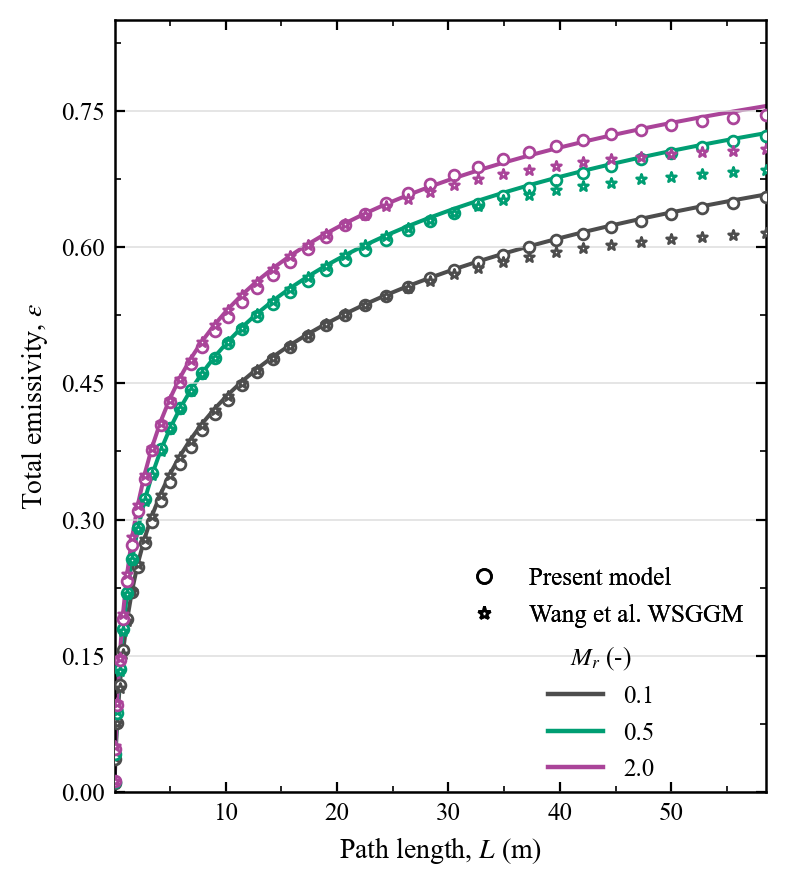

In [11]:
# Editable parameters for this figure
figsize = (4.0, 4.5)
selected_mole_ratios = [0.1, 0.5, 2.0]
annotation_xy = (0.97, 0.96)
series_legend_loc = "lower left"
series_legend_anchor = (0.65, 0.0)
series_legend_ncol = 1
model_legend_loc = "lower right"
model_legend_anchor = (0.98, 0.2)
x_limits = None
y_limits = None
save_stem = "emissivity_vs_path_length_t_1100K"

temperature_value = 1100.0
path_order = np.argsort(val_l)
val_l_sorted = val_l[path_order]
selected_mole_indices = [gvp.nearest_index(val_mr, mr) for mr in selected_mole_ratios]
temperature_index = gvp.nearest_index(val_t, temperature_value)

x_values = val_l_sorted
reference_curves = [val_ref[idx, temperature_index, :][path_order] for idx in selected_mole_indices]
rsm_curves = [val_rsm[idx, temperature_index, :][path_order] for idx in selected_mole_indices]
wang_curves = [val_wang[idx, temperature_index, :][path_order] for idx in selected_mole_indices]
series_labels = ["{:.1f}".format(mr_value) for mr_value in selected_mole_ratios]
annotation_text = "$T = {:.0f}$ K".format(temperature_value)

if y_limits is None:
    y_limits = gvp.emissivity_ylim(reference_curves, rsm_curves, wang_curves)
if x_limits is None:
    x_limits = (float(x_values.min()), float(x_values.max()))

colors = gvp.choose_series_colors(len(series_labels))
fig, ax = plt.subplots(figsize=figsize)

for color, reference_curve, rsm_curve, wang_curve in zip(colors, reference_curves, rsm_curves, wang_curves):
    ax.plot(x_values, reference_curve, color=color, linewidth=1.45, zorder=1)
    ax.scatter(
        x_values,
        rsm_curve,
        marker="o",
        s=15,
        facecolors="white",
        edgecolors=color,
        linewidths=1.0,
        zorder=3,
    )
    ax.scatter(
        x_values,
        wang_curve,
        marker="*",
        s=14,
        facecolors="white",
        edgecolors=color,
        linewidths=0.95,
        zorder=3,
    )

gvp.style_axes(ax, grid_axis="y", logx=False)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_xlabel(r"Path length, $L$ (m)")
ax.set_ylabel(r"Total emissivity, $\varepsilon$")
# gvp.annotate_box(ax, annotation_text, annotation_xy, ha="right")

series_handles = [
    Line2D([0], [0], color=color, linewidth=1.6, label=label)
    for color, label in zip(colors, series_labels)
]
legend_series = ax.legend(
    handles=series_handles,
    title=r"$M_r$ (-)",
    loc=series_legend_loc,
    bbox_to_anchor=series_legend_anchor,
    borderaxespad=0.0,
    ncol=series_legend_ncol,
    columnspacing=0.9,
    handlelength=2.2,
)

model_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=5.0,
        label="Present model",
    ),
    Line2D(
        [0], [0],
        linestyle="None",
        marker="*",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=4.8,
        label="Wang et al. WSGGM",
    ),
]
legend_models = ax.legend(
    handles=model_handles,
    loc=model_legend_loc,
    bbox_to_anchor=model_legend_anchor,
    borderaxespad=0.0,
)

ax.add_artist(legend_series)
ax.add_artist(legend_models)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_t_1700K.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\emissivity_vs_path_length_t_1700K.pdf


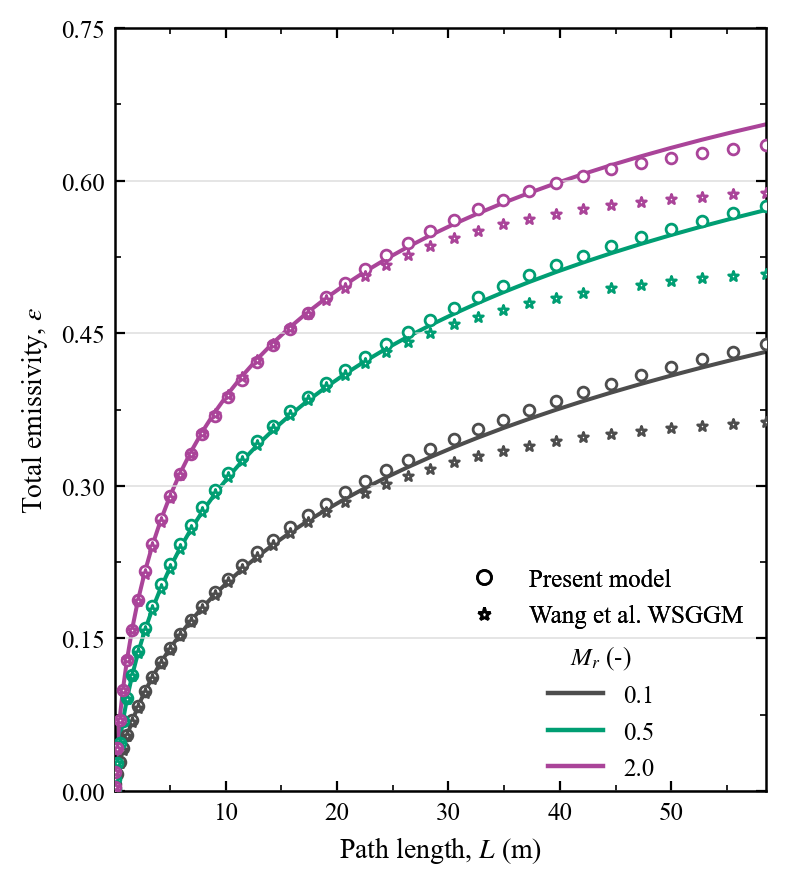

In [12]:
# Editable parameters for this figure
figsize = (4.0, 4.5)
selected_mole_ratios = [0.1, 0.5, 2.0]
annotation_xy = (0.97, 0.96)
series_legend_loc = "lower left"
series_legend_anchor = (0.65, 0.0)
series_legend_ncol = 1
model_legend_loc = "lower right"
model_legend_anchor = (0.98, 0.2)
x_limits = None
y_limits = None
save_stem = "emissivity_vs_path_length_t_1700K"

temperature_value = 1700.0
path_order = np.argsort(val_l)
val_l_sorted = val_l[path_order]
selected_mole_indices = [gvp.nearest_index(val_mr, mr) for mr in selected_mole_ratios]
temperature_index = gvp.nearest_index(val_t, temperature_value)

x_values = val_l_sorted
reference_curves = [val_ref[idx, temperature_index, :][path_order] for idx in selected_mole_indices]
rsm_curves = [val_rsm[idx, temperature_index, :][path_order] for idx in selected_mole_indices]
wang_curves = [val_wang[idx, temperature_index, :][path_order] for idx in selected_mole_indices]
series_labels = ["{:.1f}".format(mr_value) for mr_value in selected_mole_ratios]
annotation_text = "$T = {:.0f}$ K".format(temperature_value)

if y_limits is None:
    y_limits = gvp.emissivity_ylim(reference_curves, rsm_curves, wang_curves)
if x_limits is None:
    x_limits = (float(x_values.min()), float(x_values.max()))

colors = gvp.choose_series_colors(len(series_labels))
fig, ax = plt.subplots(figsize=figsize)

for color, reference_curve, rsm_curve, wang_curve in zip(colors, reference_curves, rsm_curves, wang_curves):
    ax.plot(x_values, reference_curve, color=color, linewidth=1.45, zorder=1)
    ax.scatter(
        x_values,
        rsm_curve,
        marker="o",
        s=15,
        facecolors="white",
        edgecolors=color,
        linewidths=1.0,
        zorder=3,
    )
    ax.scatter(
        x_values,
        wang_curve,
        marker="*",
        s=14,
        facecolors="white",
        edgecolors=color,
        linewidths=0.95,
        zorder=3,
    )

gvp.style_axes(ax, grid_axis="y", logx=False)
ax.set_xlim(*x_limits)
ax.set_ylim(*y_limits)
ax.set_xlabel(r"Path length, $L$ (m)")
ax.set_ylabel(r"Total emissivity, $\varepsilon$")
# gvp.annotate_box(ax, annotation_text, annotation_xy, ha="right")

series_handles = [
    Line2D([0], [0], color=color, linewidth=1.6, label=label)
    for color, label in zip(colors, series_labels)
]
legend_series = ax.legend(
    handles=series_handles,
    title=r"$M_r$ (-)",
    loc=series_legend_loc,
    bbox_to_anchor=series_legend_anchor,
    borderaxespad=0.0,
    ncol=series_legend_ncol,
    columnspacing=0.9,
    handlelength=2.2,
)

model_handles = [
    Line2D(
        [0], [0],
        linestyle="None",
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=5.0,
        label="Present model",
    ),
    Line2D(
        [0], [0],
        linestyle="None",
        marker="*",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.0,
        markersize=4.8,
        label="Wang et al. WSGGM",
    ),
]
legend_models = ax.legend(
    handles=model_handles,
    loc=model_legend_loc,
    bbox_to_anchor=model_legend_anchor,
    borderaxespad=0.0,
)

ax.add_artist(legend_series)
ax.add_artist(legend_models)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


## Case-By-Case Validation


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case1.1_L1.0m.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case1.1_L1.0m.pdf


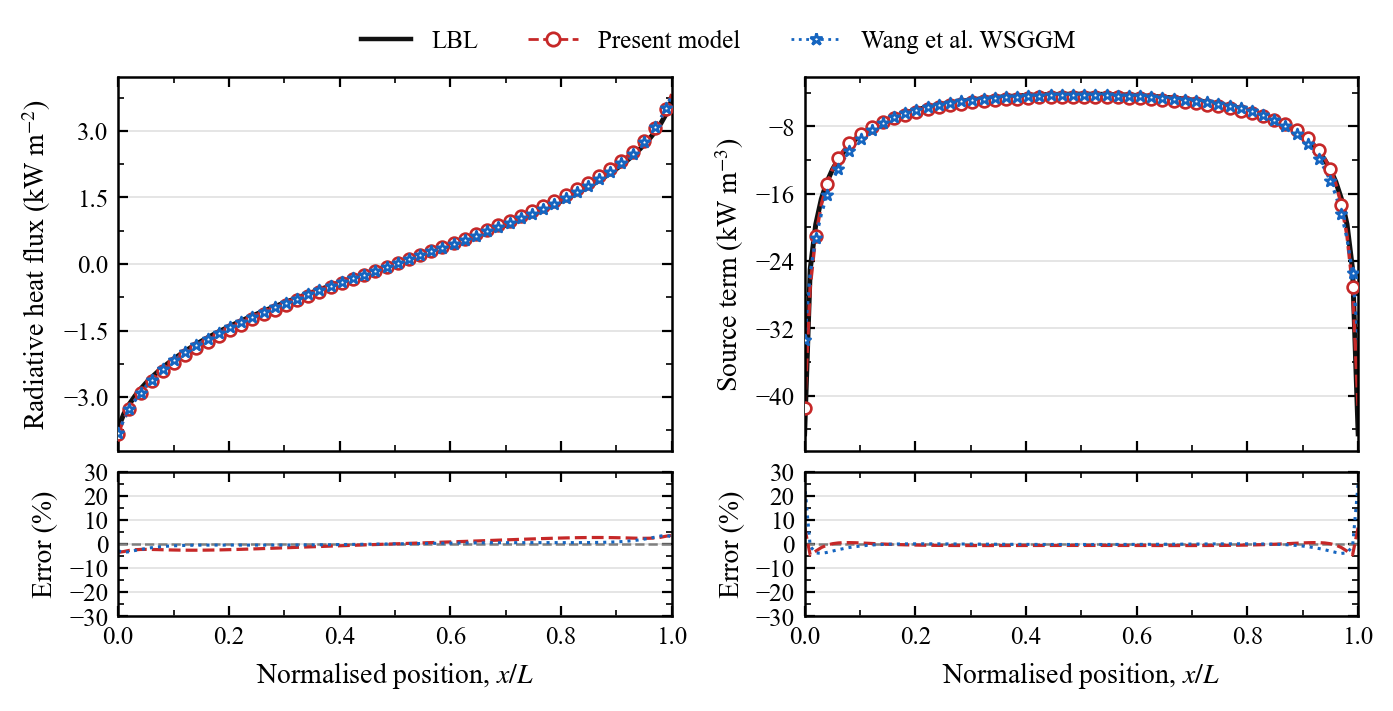

In [13]:
# Editable parameters for this figure
case_name = "Case1.1_L1.0m"
config_index = 1
figsize = (8, 3.5)
annotation_xy = (0.97, 0.96)
legend_bbox = (0.5, 0.98)
error_ylim = None
panel_labels = PANEL_LABELS
marker_step = 2
save_stem = "case_validation_Case1.1_L1.0m"

result = get_case_result(case_name, config_index)
if error_ylim is None:
    error_ylim = (-result["error_limit"], result["error_limit"])
annotation_text = "Configuration {}\n$L = {:.1f}$ m".format(result["config_index"], result["length_value"])

fig, axes = plt.subplots(2, 2, figsize=figsize, sharex="col", gridspec_kw={"height_ratios": [3.1, 1.2], "wspace": 0.24, "hspace": 0.08})
(ax_q, ax_st), (ax_q_err, ax_st_err) = axes

ax_q.plot(result["x_rel"], result["reference_q"], color=gvp.COLORS["reference"], linewidth=1.8, label="LBL")
ax_q.plot(result["x_rel"], result["rsm_q"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_q.plot(result["x_rel"], result["wang_q"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_q.scatter(result["x_rel"][::marker_step], result["rsm_q"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_q.scatter(result["x_rel"][::marker_step], result["wang_q"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_q.set_ylabel("Radiative heat flux (kW m$^{-2}$)")
ax_q.set_xlim(0.0, 1.0)
gvp.style_axes(ax_q, grid_axis="y")
gvp.add_panel_label(ax_q, "(a)", panel_labels)
# gvp.annotate_box(ax_q, annotation_text, annotation_xy, ha="right")
plt.setp(ax_q.get_xticklabels(), visible=False)

ax_q_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_q_err.set_ylabel("Error (%)")
ax_q_err.set_xlabel(r"Normalised position, $x/L$")
ax_q_err.set_xlim(0.0, 1.0)
ax_q_err.set_ylim(*error_ylim)
gvp.style_axes(ax_q_err, grid_axis="y")
gvp.add_panel_label(ax_q_err, "(b)", panel_labels)

ax_st.plot(result["x_rel"], result["reference_st"], color=gvp.COLORS["reference"], linewidth=1.8)
ax_st.plot(result["x_rel"], result["rsm_st"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_st.plot(result["x_rel"], result["wang_st"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_st.scatter(result["x_rel"][::marker_step], result["rsm_st"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_st.scatter(result["x_rel"][::marker_step], result["wang_st"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_st.set_ylabel("Source term (kW m$^{-3}$)")
ax_st.set_xlim(0.0, 1.0)
gvp.style_axes(ax_st, grid_axis="y")
gvp.add_panel_label(ax_st, "(c)", panel_labels)
plt.setp(ax_st.get_xticklabels(), visible=False)

ax_st_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_st_err.set_ylabel("Error (%)")
ax_st_err.set_xlabel(r"Normalised position, $x/L$")
ax_st_err.set_xlim(0.0, 1.0)
ax_st_err.set_ylim(*error_ylim)
gvp.style_axes(ax_st_err, grid_axis="y")
gvp.add_panel_label(ax_st_err, "(d)", panel_labels)

fig.legend(handles=[
    Line2D([0], [0], color=gvp.COLORS["reference"], linewidth=1.6, label="LBL"),
    Line2D([0], [0], color=gvp.COLORS["present"], linewidth=1.0, linestyle="--", marker="o", markerfacecolor="white", markeredgecolor=gvp.COLORS["present"], markersize=4.8, label="Present model"),
    Line2D([0], [0], color=gvp.COLORS["wang"], linewidth=1.0, linestyle=":", marker="*", markerfacecolor="white", markeredgecolor=gvp.COLORS["wang"], markersize=4.6, label="Wang et al. WSGGM"),
], loc="upper center", bbox_to_anchor=legend_bbox, ncol=3)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case1.2_L1.0m.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case1.2_L1.0m.pdf


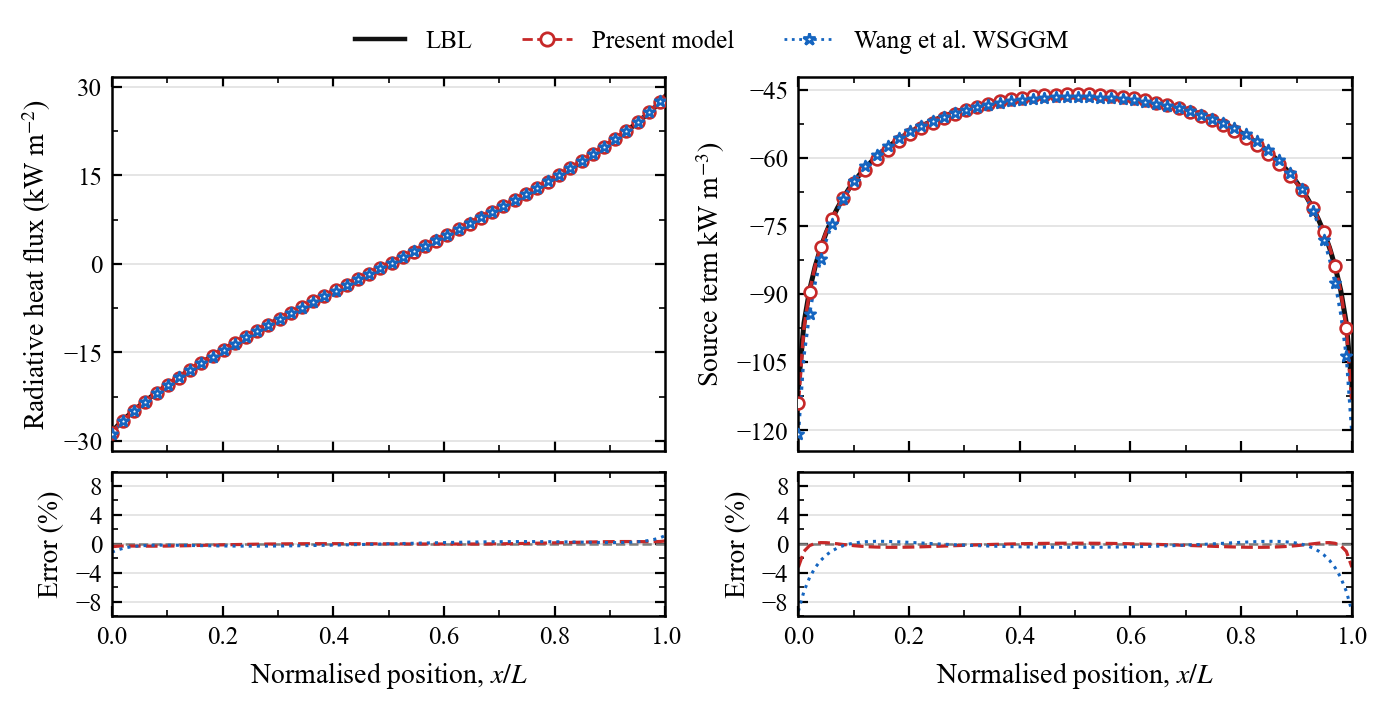

In [14]:
# Editable parameters for this figure
case_name = "Case1.2_L1.0m"
config_index = 2
figsize = (8, 3.5)
annotation_xy = (0.97, 0.96)
legend_bbox = (0.5, 0.98)
error_ylim = None
panel_labels = PANEL_LABELS
marker_step = 2
save_stem = "case_validation_Case1.2_L1.0m"

result = get_case_result(case_name, config_index)
if error_ylim is None:
    error_ylim = (-result["error_limit"], result["error_limit"])
annotation_text = "Configuration {}\n$L = {:.1f}$ m".format(result["config_index"], result["length_value"])

fig, axes = plt.subplots(2, 2, figsize=figsize, sharex="col", gridspec_kw={"height_ratios": [3.1, 1.2], "wspace": 0.24, "hspace": 0.08})
(ax_q, ax_st), (ax_q_err, ax_st_err) = axes

ax_q.plot(result["x_rel"], result["reference_q"], color=gvp.COLORS["reference"], linewidth=1.8, label="LBL")
ax_q.plot(result["x_rel"], result["rsm_q"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_q.plot(result["x_rel"], result["wang_q"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_q.scatter(result["x_rel"][::marker_step], result["rsm_q"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_q.scatter(result["x_rel"][::marker_step], result["wang_q"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_q.set_ylabel("Radiative heat flux (kW m$^{-2}$)")
ax_q.set_xlim(0.0, 1.0)
gvp.style_axes(ax_q, grid_axis="y")
gvp.add_panel_label(ax_q, "(a)", panel_labels)
# gvp.annotate_box(ax_q, annotation_text, annotation_xy, ha="right")
plt.setp(ax_q.get_xticklabels(), visible=False)

ax_q_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_q_err.set_ylabel("Error (%)")
ax_q_err.set_xlabel(r"Normalised position, $x/L$")
ax_q_err.set_xlim(0.0, 1.0)
ax_q_err.set_ylim(*error_ylim)
gvp.style_axes(ax_q_err, grid_axis="y")
gvp.add_panel_label(ax_q_err, "(b)", panel_labels)

ax_st.plot(result["x_rel"], result["reference_st"], color=gvp.COLORS["reference"], linewidth=1.8)
ax_st.plot(result["x_rel"], result["rsm_st"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_st.plot(result["x_rel"], result["wang_st"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_st.scatter(result["x_rel"][::marker_step], result["rsm_st"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_st.scatter(result["x_rel"][::marker_step], result["wang_st"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_st.set_ylabel("Source term kW m$^{-3}$)")
ax_st.set_xlim(0.0, 1.0)
gvp.style_axes(ax_st, grid_axis="y")
gvp.add_panel_label(ax_st, "(c)", panel_labels)
plt.setp(ax_st.get_xticklabels(), visible=False)

ax_st_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_st_err.set_ylabel("Error (%)")
ax_st_err.set_xlabel(r"Normalised position, $x/L$")
ax_st_err.set_xlim(0.0, 1.0)
ax_st_err.set_ylim(*error_ylim)
gvp.style_axes(ax_st_err, grid_axis="y")
gvp.add_panel_label(ax_st_err, "(d)", panel_labels)

fig.legend(handles=[
    Line2D([0], [0], color=gvp.COLORS["reference"], linewidth=1.6, label="LBL"),
    Line2D([0], [0], color=gvp.COLORS["present"], linewidth=1.0, linestyle="--", marker="o", markerfacecolor="white", markeredgecolor=gvp.COLORS["present"], markersize=4.8, label="Present model"),
    Line2D([0], [0], color=gvp.COLORS["wang"], linewidth=1.0, linestyle=":", marker="*", markerfacecolor="white", markeredgecolor=gvp.COLORS["wang"], markersize=4.6, label="Wang et al. WSGGM"),
], loc="upper center", bbox_to_anchor=legend_bbox, ncol=3)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case1.3_L1.0m.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case1.3_L1.0m.pdf


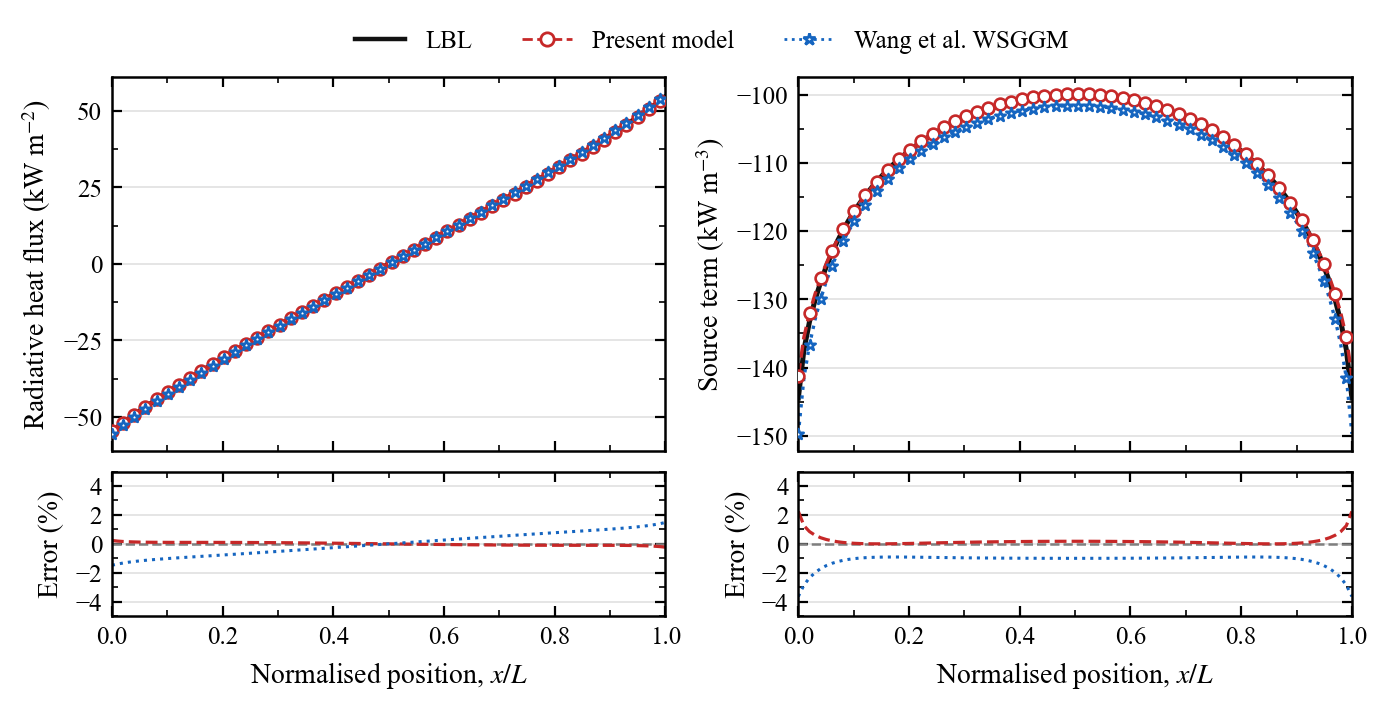

In [15]:
# Editable parameters for this figure
case_name = "Case1.3_L1.0m"
config_index = 3
figsize = (8, 3.5)
annotation_xy = (0.97, 0.96)
legend_bbox = (0.5, 0.98)
error_ylim = None
panel_labels = PANEL_LABELS
marker_step = 2
save_stem = "case_validation_Case1.3_L1.0m"

result = get_case_result(case_name, config_index)
if error_ylim is None:
    error_ylim = (-result["error_limit"], result["error_limit"])
# annotation_text = "Configuration {}\n$L = {:.1f}$ m".format(result["config_index"], result["length_value"])

fig, axes = plt.subplots(2, 2, figsize=figsize, sharex="col", gridspec_kw={"height_ratios": [3.1, 1.2], "wspace": 0.24, "hspace": 0.08})
(ax_q, ax_st), (ax_q_err, ax_st_err) = axes

ax_q.plot(result["x_rel"], result["reference_q"], color=gvp.COLORS["reference"], linewidth=1.8, label="LBL")
ax_q.plot(result["x_rel"], result["rsm_q"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_q.plot(result["x_rel"], result["wang_q"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_q.scatter(result["x_rel"][::marker_step], result["rsm_q"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_q.scatter(result["x_rel"][::marker_step], result["wang_q"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_q.set_ylabel("Radiative heat flux (kW m$^{-2}$)")
ax_q.set_xlim(0.0, 1.0)
gvp.style_axes(ax_q, grid_axis="y")
gvp.add_panel_label(ax_q, "(a)", panel_labels)
# gvp.annotate_box(ax_q, annotation_text, annotation_xy, ha="right")
plt.setp(ax_q.get_xticklabels(), visible=False)

ax_q_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_q_err.set_ylabel("Error (%)")
ax_q_err.set_xlabel(r"Normalised position, $x/L$")
ax_q_err.set_xlim(0.0, 1.0)
ax_q_err.set_ylim(*error_ylim)
gvp.style_axes(ax_q_err, grid_axis="y")
gvp.add_panel_label(ax_q_err, "(b)", panel_labels)

ax_st.plot(result["x_rel"], result["reference_st"], color=gvp.COLORS["reference"], linewidth=1.8)
ax_st.plot(result["x_rel"], result["rsm_st"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_st.plot(result["x_rel"], result["wang_st"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_st.scatter(result["x_rel"][::marker_step], result["rsm_st"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_st.scatter(result["x_rel"][::marker_step], result["wang_st"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_st.set_ylabel("Source term (kW m$^{-3}$)")
ax_st.set_xlim(0.0, 1.0)
gvp.style_axes(ax_st, grid_axis="y")
gvp.add_panel_label(ax_st, "(c)", panel_labels)
plt.setp(ax_st.get_xticklabels(), visible=False)

ax_st_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_st_err.set_ylabel("Error (%)")
ax_st_err.set_xlabel(r"Normalised position, $x/L$")
ax_st_err.set_xlim(0.0, 1.0)
ax_st_err.set_ylim(*error_ylim)
gvp.style_axes(ax_st_err, grid_axis="y")
gvp.add_panel_label(ax_st_err, "(d)", panel_labels)

fig.legend(handles=[
    Line2D([0], [0], color=gvp.COLORS["reference"], linewidth=1.6, label="LBL"),
    Line2D([0], [0], color=gvp.COLORS["present"], linewidth=1.0, linestyle="--", marker="o", markerfacecolor="white", markeredgecolor=gvp.COLORS["present"], markersize=4.8, label="Present model"),
    Line2D([0], [0], color=gvp.COLORS["wang"], linewidth=1.0, linestyle=":", marker="*", markerfacecolor="white", markeredgecolor=gvp.COLORS["wang"], markersize=4.6, label="Wang et al. WSGGM"),
], loc="upper center", bbox_to_anchor=legend_bbox, ncol=3)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case2.1_L1.0m.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case2.1_L1.0m.pdf


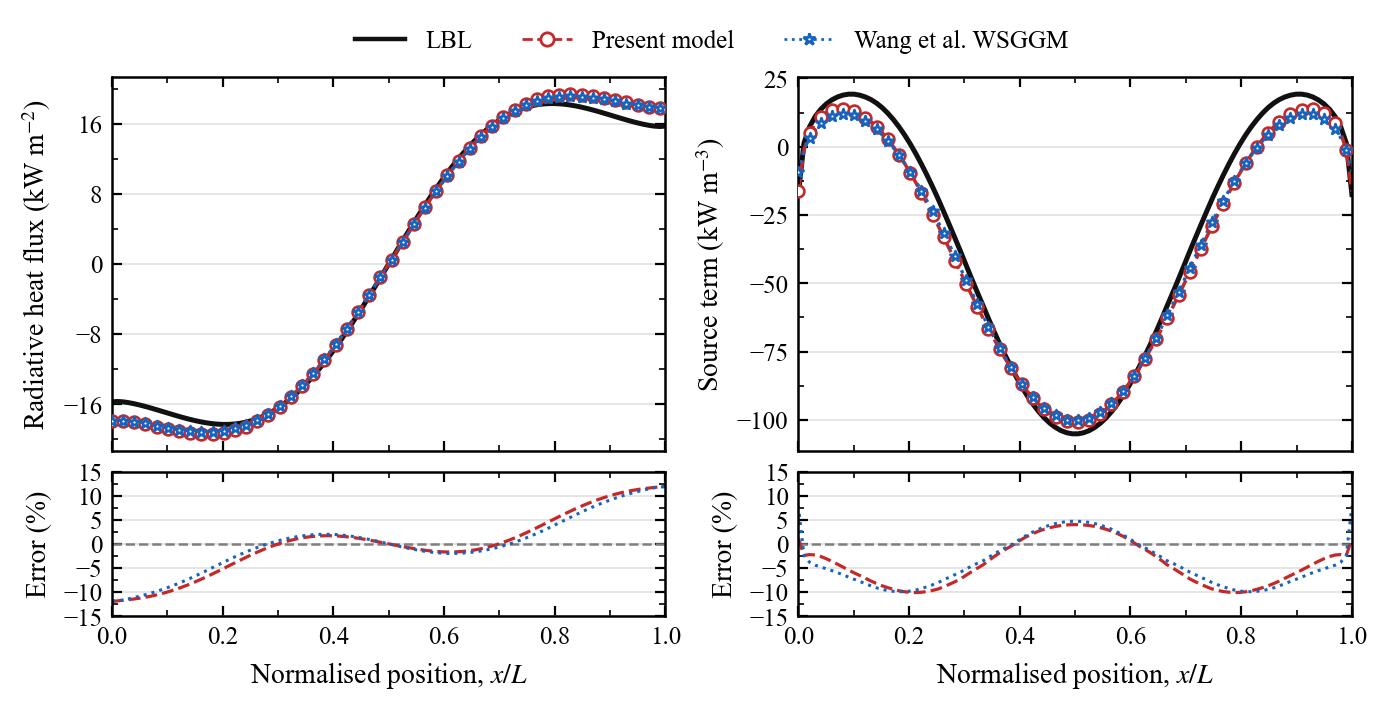

In [16]:
# Editable parameters for this figure
case_name = "Case2.1_L1.0m"
config_index = 4
figsize = (8, 3.5)
annotation_xy = (0.97, 0.96)
legend_bbox = (0.5, 0.98)
error_ylim = None
panel_labels = PANEL_LABELS
marker_step = 2
save_stem = "case_validation_Case2.1_L1.0m"

result = get_case_result(case_name, config_index)
if error_ylim is None:
    error_ylim = (-result["error_limit"], result["error_limit"])
annotation_text = "Configuration {}\n$L = {:.1f}$ m".format(result["config_index"], result["length_value"])

fig, axes = plt.subplots(2, 2, figsize=figsize, sharex="col", gridspec_kw={"height_ratios": [3.1, 1.2], "wspace": 0.24, "hspace": 0.08})
(ax_q, ax_st), (ax_q_err, ax_st_err) = axes

ax_q.plot(result["x_rel"], result["reference_q"], color=gvp.COLORS["reference"], linewidth=1.8, label="LBL")
ax_q.plot(result["x_rel"], result["rsm_q"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_q.plot(result["x_rel"], result["wang_q"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_q.scatter(result["x_rel"][::marker_step], result["rsm_q"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_q.scatter(result["x_rel"][::marker_step], result["wang_q"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_q.set_ylabel("Radiative heat flux (kW m$^{-2}$)")
ax_q.set_xlim(0.0, 1.0)
gvp.style_axes(ax_q, grid_axis="y")
gvp.add_panel_label(ax_q, "(a)", panel_labels)
# gvp.annotate_box(ax_q, annotation_text, annotation_xy, ha="right")
plt.setp(ax_q.get_xticklabels(), visible=False)

ax_q_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_q_err.set_ylabel("Error (%)")
ax_q_err.set_xlabel(r"Normalised position, $x/L$")
ax_q_err.set_xlim(0.0, 1.0)
ax_q_err.set_ylim(*error_ylim)
gvp.style_axes(ax_q_err, grid_axis="y")
gvp.add_panel_label(ax_q_err, "(b)", panel_labels)

ax_st.plot(result["x_rel"], result["reference_st"], color=gvp.COLORS["reference"], linewidth=1.8)
ax_st.plot(result["x_rel"], result["rsm_st"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_st.plot(result["x_rel"], result["wang_st"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_st.scatter(result["x_rel"][::marker_step], result["rsm_st"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_st.scatter(result["x_rel"][::marker_step], result["wang_st"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_st.set_ylabel("Source term (kW m$^{-3}$)")
ax_st.set_xlim(0.0, 1.0)
gvp.style_axes(ax_st, grid_axis="y")
gvp.add_panel_label(ax_st, "(c)", panel_labels)
plt.setp(ax_st.get_xticklabels(), visible=False)

ax_st_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_st_err.set_ylabel("Error (%)")
ax_st_err.set_xlabel(r"Normalised position, $x/L$")
ax_st_err.set_xlim(0.0, 1.0)
ax_st_err.set_ylim(*error_ylim)
gvp.style_axes(ax_st_err, grid_axis="y")
gvp.add_panel_label(ax_st_err, "(d)", panel_labels)

fig.legend(handles=[
    Line2D([0], [0], color=gvp.COLORS["reference"], linewidth=1.6, label="LBL"),
    Line2D([0], [0], color=gvp.COLORS["present"], linewidth=1.0, linestyle="--", marker="o", markerfacecolor="white", markeredgecolor=gvp.COLORS["present"], markersize=4.8, label="Present model"),
    Line2D([0], [0], color=gvp.COLORS["wang"], linewidth=1.0, linestyle=":", marker="*", markerfacecolor="white", markeredgecolor=gvp.COLORS["wang"], markersize=4.6, label="Wang et al. WSGGM"),
], loc="upper center", bbox_to_anchor=legend_bbox, ncol=3)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case2.2_L1.0m.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case2.2_L1.0m.pdf


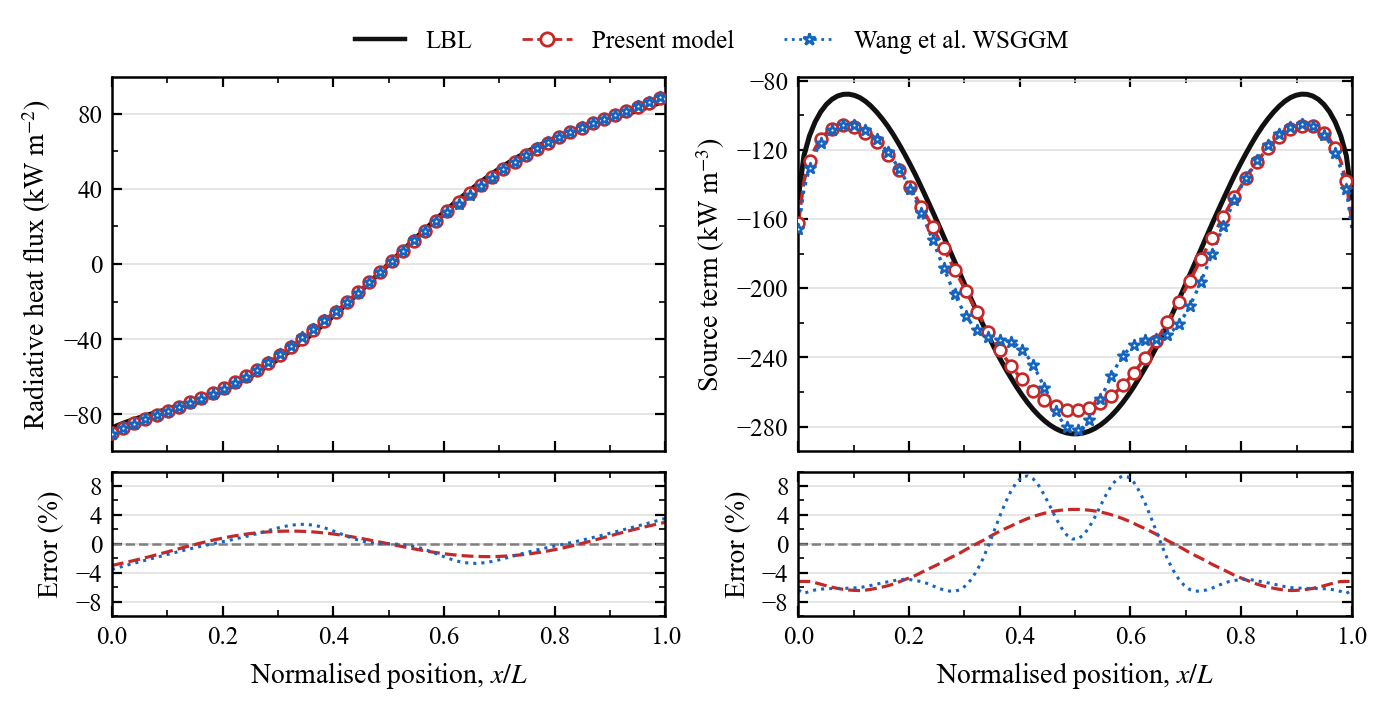

In [17]:
# Editable parameters for this figure
case_name = "Case2.2_L1.0m"
config_index = 5
figsize = (8, 3.5)
annotation_xy = (0.97, 0.96)
legend_bbox = (0.5, 0.98)
error_ylim = None
panel_labels = PANEL_LABELS
marker_step = 2
save_stem = "case_validation_Case2.2_L1.0m"

result = get_case_result(case_name, config_index)
if error_ylim is None:
    error_ylim = (-result["error_limit"], result["error_limit"])
annotation_text = "Configuration {}\n$L = {:.1f}$ m".format(result["config_index"], result["length_value"])

fig, axes = plt.subplots(2, 2, figsize=figsize, sharex="col", gridspec_kw={"height_ratios": [3.1, 1.2], "wspace": 0.24, "hspace": 0.08})
(ax_q, ax_st), (ax_q_err, ax_st_err) = axes

ax_q.plot(result["x_rel"], result["reference_q"], color=gvp.COLORS["reference"], linewidth=1.8, label="LBL")
ax_q.plot(result["x_rel"], result["rsm_q"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_q.plot(result["x_rel"], result["wang_q"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_q.scatter(result["x_rel"][::marker_step], result["rsm_q"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_q.scatter(result["x_rel"][::marker_step], result["wang_q"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_q.set_ylabel("Radiative heat flux (kW m$^{-2}$)")
ax_q.set_xlim(0.0, 1.0)
gvp.style_axes(ax_q, grid_axis="y")
gvp.add_panel_label(ax_q, "(a)", panel_labels)
# gvp.annotate_box(ax_q, annotation_text, annotation_xy, ha="right")
plt.setp(ax_q.get_xticklabels(), visible=False)

ax_q_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_q_err.set_ylabel("Error (%)")
ax_q_err.set_xlabel(r"Normalised position, $x/L$")
ax_q_err.set_xlim(0.0, 1.0)
ax_q_err.set_ylim(*error_ylim)
gvp.style_axes(ax_q_err, grid_axis="y")
gvp.add_panel_label(ax_q_err, "(b)", panel_labels)

ax_st.plot(result["x_rel"], result["reference_st"], color=gvp.COLORS["reference"], linewidth=1.8)
ax_st.plot(result["x_rel"], result["rsm_st"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_st.plot(result["x_rel"], result["wang_st"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_st.scatter(result["x_rel"][::marker_step], result["rsm_st"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_st.scatter(result["x_rel"][::marker_step], result["wang_st"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_st.set_ylabel("Source term (kW m$^{-3}$)")
ax_st.set_xlim(0.0, 1.0)
gvp.style_axes(ax_st, grid_axis="y")
gvp.add_panel_label(ax_st, "(c)", panel_labels)
plt.setp(ax_st.get_xticklabels(), visible=False)

ax_st_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_st_err.set_ylabel("Error (%)")
ax_st_err.set_xlabel(r"Normalised position, $x/L$")
ax_st_err.set_xlim(0.0, 1.0)
ax_st_err.set_ylim(*error_ylim)
gvp.style_axes(ax_st_err, grid_axis="y")
gvp.add_panel_label(ax_st_err, "(d)", panel_labels)

fig.legend(handles=[
    Line2D([0], [0], color=gvp.COLORS["reference"], linewidth=1.6, label="LBL"),
    Line2D([0], [0], color=gvp.COLORS["present"], linewidth=1.0, linestyle="--", marker="o", markerfacecolor="white", markeredgecolor=gvp.COLORS["present"], markersize=4.8, label="Present model"),
    Line2D([0], [0], color=gvp.COLORS["wang"], linewidth=1.0, linestyle=":", marker="*", markerfacecolor="white", markeredgecolor=gvp.COLORS["wang"], markersize=4.6, label="Wang et al. WSGGM"),
], loc="upper center", bbox_to_anchor=legend_bbox, ncol=3)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case3.1_L1.0m.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case3.1_L1.0m.pdf


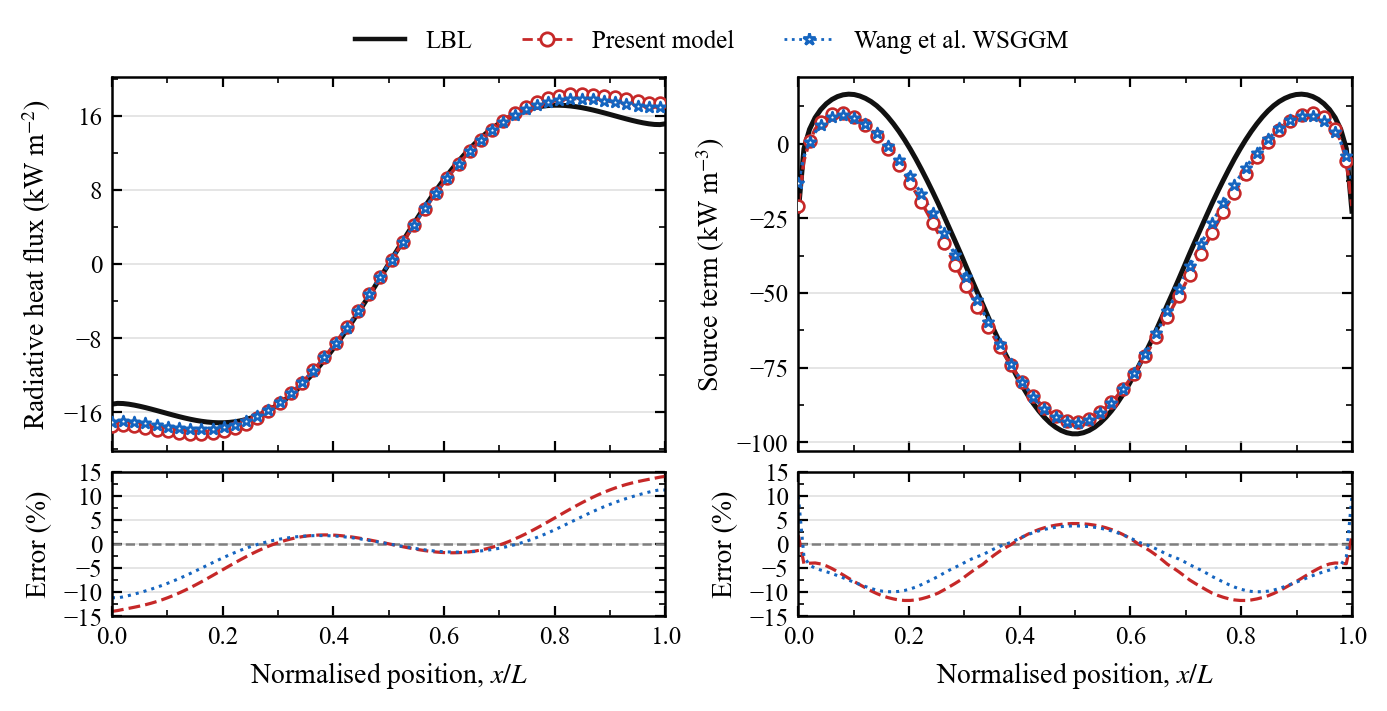

In [18]:
# Editable parameters for this figure
case_name = "Case3.1_L1.0m"
config_index = 6
figsize = (8, 3.5)
annotation_xy = (0.97, 0.96)
legend_bbox = (0.5, 0.98)
error_ylim = None
panel_labels = PANEL_LABELS
marker_step = 2
save_stem = "case_validation_Case3.1_L1.0m"

result = get_case_result(case_name, config_index)
if error_ylim is None:
    error_ylim = (-result["error_limit"], result["error_limit"])
annotation_text = "Configuration {}\n$L = {:.1f}$ m".format(result["config_index"], result["length_value"])

fig, axes = plt.subplots(2, 2, figsize=figsize, sharex="col", gridspec_kw={"height_ratios": [3.1, 1.2], "wspace": 0.24, "hspace": 0.08})
(ax_q, ax_st), (ax_q_err, ax_st_err) = axes

ax_q.plot(result["x_rel"], result["reference_q"], color=gvp.COLORS["reference"], linewidth=1.8, label="LBL")
ax_q.plot(result["x_rel"], result["rsm_q"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_q.plot(result["x_rel"], result["wang_q"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_q.scatter(result["x_rel"][::marker_step], result["rsm_q"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_q.scatter(result["x_rel"][::marker_step], result["wang_q"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_q.set_ylabel("Radiative heat flux (kW m$^{-2}$)")
ax_q.set_xlim(0.0, 1.0)
gvp.style_axes(ax_q, grid_axis="y")
gvp.add_panel_label(ax_q, "(a)", panel_labels)
# gvp.annotate_box(ax_q, annotation_text, annotation_xy, ha="right")
plt.setp(ax_q.get_xticklabels(), visible=False)

ax_q_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_q_err.set_ylabel("Error (%)")
ax_q_err.set_xlabel(r"Normalised position, $x/L$")
ax_q_err.set_xlim(0.0, 1.0)
ax_q_err.set_ylim(*error_ylim)
gvp.style_axes(ax_q_err, grid_axis="y")
gvp.add_panel_label(ax_q_err, "(b)", panel_labels)

ax_st.plot(result["x_rel"], result["reference_st"], color=gvp.COLORS["reference"], linewidth=1.8)
ax_st.plot(result["x_rel"], result["rsm_st"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_st.plot(result["x_rel"], result["wang_st"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_st.scatter(result["x_rel"][::marker_step], result["rsm_st"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_st.scatter(result["x_rel"][::marker_step], result["wang_st"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_st.set_ylabel("Source term (kW m$^{-3}$)")
ax_st.set_xlim(0.0, 1.0)
gvp.style_axes(ax_st, grid_axis="y")
gvp.add_panel_label(ax_st, "(c)", panel_labels)
plt.setp(ax_st.get_xticklabels(), visible=False)

ax_st_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_st_err.set_ylabel("Error (%)")
ax_st_err.set_xlabel(r"Normalised position, $x/L$")
ax_st_err.set_xlim(0.0, 1.0)
ax_st_err.set_ylim(*error_ylim)
gvp.style_axes(ax_st_err, grid_axis="y")
gvp.add_panel_label(ax_st_err, "(d)", panel_labels)

fig.legend(handles=[
    Line2D([0], [0], color=gvp.COLORS["reference"], linewidth=1.6, label="LBL"),
    Line2D([0], [0], color=gvp.COLORS["present"], linewidth=1.0, linestyle="--", marker="o", markerfacecolor="white", markeredgecolor=gvp.COLORS["present"], markersize=4.8, label="Present model"),
    Line2D([0], [0], color=gvp.COLORS["wang"], linewidth=1.0, linestyle=":", marker="*", markerfacecolor="white", markeredgecolor=gvp.COLORS["wang"], markersize=4.6, label="Wang et al. WSGGM"),
], loc="upper center", bbox_to_anchor=legend_bbox, ncol=3)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case3.2_L1.0m.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_validation_Case3.2_L1.0m.pdf


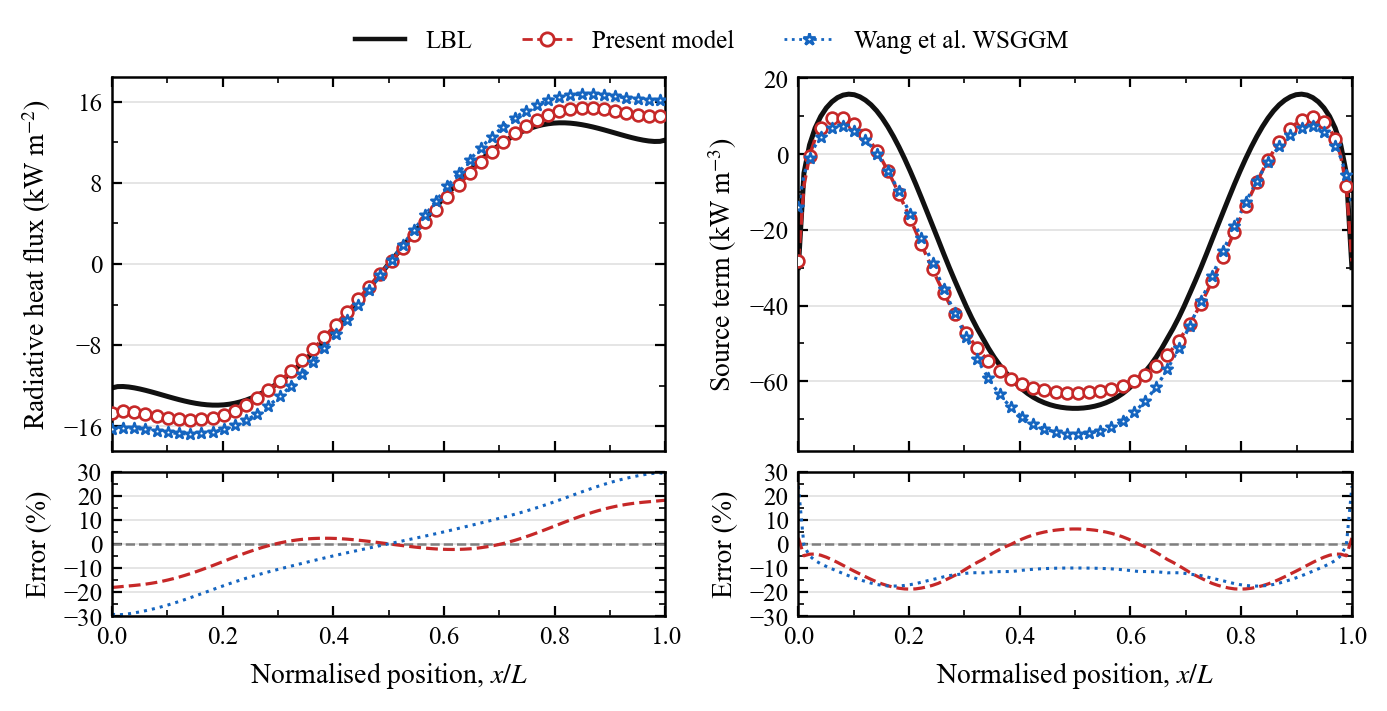

In [19]:
# Editable parameters for this figure
case_name = "Case3.2_L1.0m"
config_index = 7
figsize = (8, 3.5)
annotation_xy = (0.97, 0.96)
legend_bbox = (0.5, 0.98)
error_ylim = None
panel_labels = PANEL_LABELS
marker_step = 2
save_stem = "case_validation_Case3.2_L1.0m"

result = get_case_result(case_name, config_index)
if error_ylim is None:
    error_ylim = (-result["error_limit"], result["error_limit"])
annotation_text = "Configuration {}\n$L = {:.1f}$ m".format(result["config_index"], result["length_value"])

fig, axes = plt.subplots(2, 2, figsize=figsize, sharex="col", gridspec_kw={"height_ratios": [3.1, 1.2], "wspace": 0.24, "hspace": 0.08})
(ax_q, ax_st), (ax_q_err, ax_st_err) = axes

ax_q.plot(result["x_rel"], result["reference_q"], color=gvp.COLORS["reference"], linewidth=1.8, label="LBL")
ax_q.plot(result["x_rel"], result["rsm_q"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_q.plot(result["x_rel"], result["wang_q"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_q.scatter(result["x_rel"][::marker_step], result["rsm_q"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_q.scatter(result["x_rel"][::marker_step], result["wang_q"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_q.set_ylabel("Radiative heat flux (kW m$^{-2}$)")
ax_q.set_xlim(0.0, 1.0)
gvp.style_axes(ax_q, grid_axis="y")
gvp.add_panel_label(ax_q, "(a)", panel_labels)
# gvp.annotate_box(ax_q, annotation_text, annotation_xy, ha="right")
plt.setp(ax_q.get_xticklabels(), visible=False)

ax_q_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_q_err.plot(result["x_rel"], result["delta_q_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_q_err.set_ylabel("Error (%)")
ax_q_err.set_xlabel(r"Normalised position, $x/L$")
ax_q_err.set_xlim(0.0, 1.0)
ax_q_err.set_ylim(*error_ylim)
gvp.style_axes(ax_q_err, grid_axis="y")
gvp.add_panel_label(ax_q_err, "(b)", panel_labels)

ax_st.plot(result["x_rel"], result["reference_st"], color=gvp.COLORS["reference"], linewidth=1.8)
ax_st.plot(result["x_rel"], result["rsm_st"], color=gvp.COLORS["present"], linewidth=1.25, linestyle="--")
ax_st.plot(result["x_rel"], result["wang_st"], color=gvp.COLORS["wang"], linewidth=1.2, linestyle=":")
ax_st.scatter(result["x_rel"][::marker_step], result["rsm_st"][::marker_step], marker="o", s=18, facecolors="white", edgecolors=gvp.COLORS["present"], linewidths=0.95, zorder=3)
ax_st.scatter(result["x_rel"][::marker_step], result["wang_st"][::marker_step], marker="*", s=16, facecolors="white", edgecolors=gvp.COLORS["wang"], linewidths=0.9, zorder=3)
ax_st.set_ylabel("Source term (kW m$^{-3}$)")
ax_st.set_xlim(0.0, 1.0)
gvp.style_axes(ax_st, grid_axis="y")
gvp.add_panel_label(ax_st, "(c)", panel_labels)
plt.setp(ax_st.get_xticklabels(), visible=False)

ax_st_err.axhline(0.0, color=gvp.COLORS["zero"], linewidth=0.9, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_rsm"], color=gvp.COLORS["present"], linewidth=1.15, linestyle="--")
ax_st_err.plot(result["x_rel"], result["delta_st_wang"], color=gvp.COLORS["wang"], linewidth=1.1, linestyle=":")
ax_st_err.set_ylabel("Error (%)")
ax_st_err.set_xlabel(r"Normalised position, $x/L$")
ax_st_err.set_xlim(0.0, 1.0)
ax_st_err.set_ylim(*error_ylim)
gvp.style_axes(ax_st_err, grid_axis="y")
gvp.add_panel_label(ax_st_err, "(d)", panel_labels)

fig.legend(handles=[
    Line2D([0], [0], color=gvp.COLORS["reference"], linewidth=1.6, label="LBL"),
    Line2D([0], [0], color=gvp.COLORS["present"], linewidth=1.0, linestyle="--", marker="o", markerfacecolor="white", markeredgecolor=gvp.COLORS["present"], markersize=4.8, label="Present model"),
    Line2D([0], [0], color=gvp.COLORS["wang"], linewidth=1.0, linestyle=":", marker="*", markerfacecolor="white", markeredgecolor=gvp.COLORS["wang"], markersize=4.6, label="Wang et al. WSGGM"),
], loc="upper center", bbox_to_anchor=legend_bbox, ncol=3)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_error_summary.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_error_summary.pdf


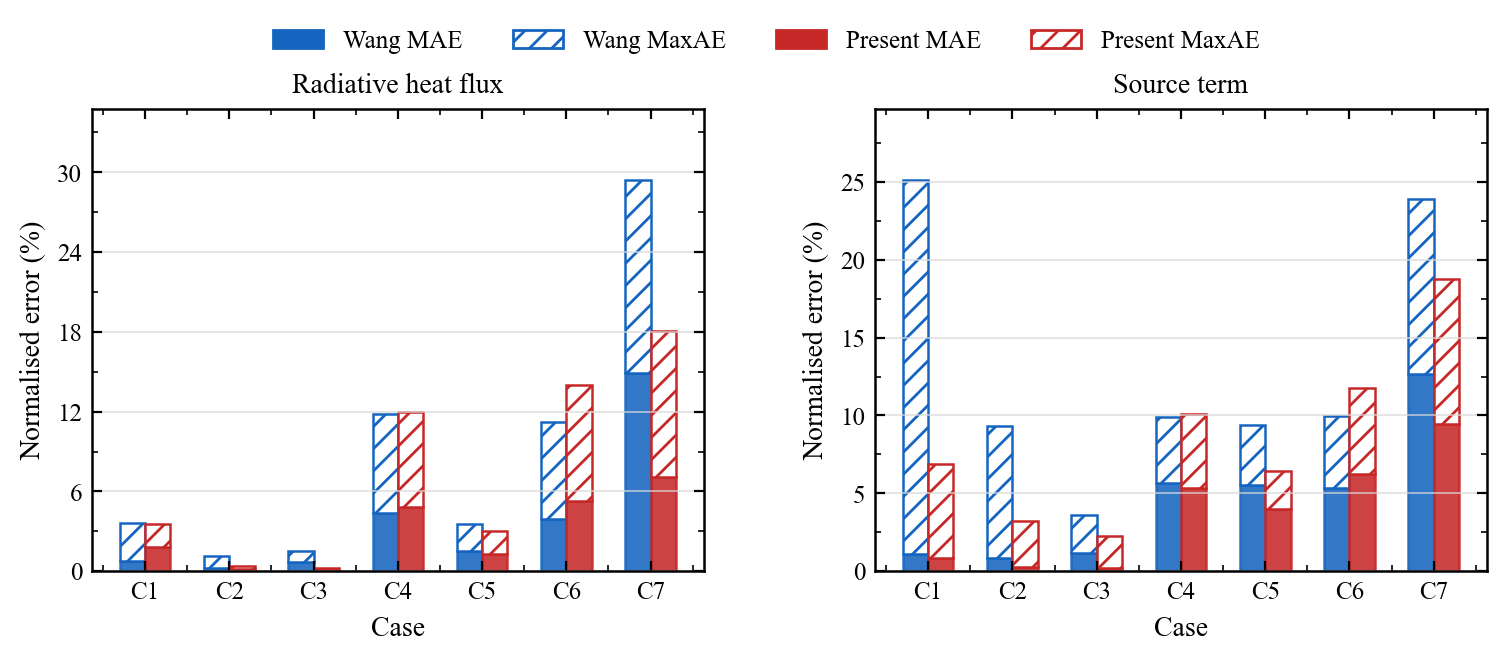

In [20]:
# Editable parameters for this figure
figsize = (9, 3)
legend_bbox = (0.5, 1.05)
panel_labels = PANEL_LABELS
y_padding_factor = 1.18
width = 0.3
save_stem = "case_error_summary"

summary_rows = []
for index, path in enumerate(CASE_FILES, start=1):
    result = get_case_result(path.stem, index)
    summary_rows.append({
        "config_label": "C{}".format(index),
        "wang_mae_q": float(np.mean(np.abs(result["delta_q_wang"]))),
        "wang_maxae_q": float(np.max(np.abs(result["delta_q_wang"]))),
        "wang_mae_st": float(np.mean(np.abs(result["delta_st_wang"]))),
        "wang_maxae_st": float(np.max(np.abs(result["delta_st_wang"]))),
        "rsm_mae_q": float(np.mean(np.abs(result["delta_q_rsm"]))),
        "rsm_maxae_q": float(np.max(np.abs(result["delta_q_rsm"]))),
        "rsm_mae_st": float(np.mean(np.abs(result["delta_st_rsm"]))),
        "rsm_maxae_st": float(np.max(np.abs(result["delta_st_rsm"]))),
    })

case_labels = [row["config_label"] for row in summary_rows]
x = np.arange(len(summary_rows))

fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"wspace": 0.28})
plot_specs = [
    (axes[0], "rsm_mae_q", "rsm_maxae_q", "wang_mae_q", "wang_maxae_q", "Radiative heat flux", "(a)"),
    (axes[1], "rsm_mae_st", "rsm_maxae_st", "wang_mae_st", "wang_maxae_st", "Source term", "(b)"),
]

for ax, rsm_mae_key, rsm_max_key, wang_mae_key, wang_max_key, title, panel_label in plot_specs:
    wang_mae = np.asarray([row[wang_mae_key] for row in summary_rows], dtype=float)
    wang_cap = np.asarray([row[wang_max_key] for row in summary_rows], dtype=float)
    rsm_mae = np.asarray([row[rsm_mae_key] for row in summary_rows], dtype=float)
    rsm_cap = np.asarray([row[rsm_max_key] for row in summary_rows], dtype=float)

    ax.bar(
        x - width / 2, wang_mae, width,
        color=gvp.COLORS["wang"], alpha=0.88,
        edgecolor=gvp.COLORS["wang"], linewidth=0.9,
    )
    ax.bar(
        x - width / 2, np.maximum(0.0, wang_cap - wang_mae), width,
        bottom=wang_mae,
        facecolor="white", edgecolor=gvp.COLORS["wang"],
        hatch="///", linewidth=0.9,
    )
    ax.bar(
        x + width / 2, rsm_mae, width,
        color=gvp.COLORS["present"], alpha=0.88,
        edgecolor=gvp.COLORS["present"], linewidth=0.9,
    )
    ax.bar(
        x + width / 2, np.maximum(0.0, rsm_cap - rsm_mae), width,
        bottom=rsm_mae,
        facecolor="white", edgecolor=gvp.COLORS["present"],
        hatch="///", linewidth=0.9,
    )

    # for x_coord, total in zip(x - width / 2, wang_cap):
    #     ax.text(x_coord, total + 0.6, "{:.1f}".format(total), ha="center", va="bottom", fontsize=8.2, color=gvp.COLORS["wang"])
    # for x_coord, total in zip(x + width / 2, rsm_cap):
    #     ax.text(x_coord, total + 0.6, "{:.1f}".format(total), ha="center", va="bottom", fontsize=8.2, color=gvp.COLORS["present"])

    gvp.style_axes(ax, grid_axis="y")
    ax.set_xticks(x)
    ax.set_xticklabels(case_labels)
    ax.set_xlabel("Case")
    ax.set_title(title)
    ax.set_ylabel("Normalised error (%)")
    ax.set_ylim(0.0, max(float(np.max(wang_cap)), float(np.max(rsm_cap))) * y_padding_factor)
    gvp.add_panel_label(ax, panel_label, panel_labels)

legend_handles = [
    Patch(facecolor=gvp.COLORS["wang"], edgecolor=gvp.COLORS["wang"], label="Wang MAE"),
    Patch(facecolor="white", edgecolor=gvp.COLORS["wang"], hatch="///", label="Wang MaxAE"),
    Patch(facecolor=gvp.COLORS["present"], edgecolor=gvp.COLORS["present"], label="Present MAE"),
    Patch(facecolor="white", edgecolor=gvp.COLORS["present"], hatch="///", label="Present MaxAE"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=legend_bbox, ncol=4)

maybe_save(fig, save_stem if SAVE_FIGURES else None)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11780\124112353.py:2: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_error_summary.png
Saved E:\JupyterProjects\RSM_WSGG\results\img\publication_notebook\case_error_summary.pdf


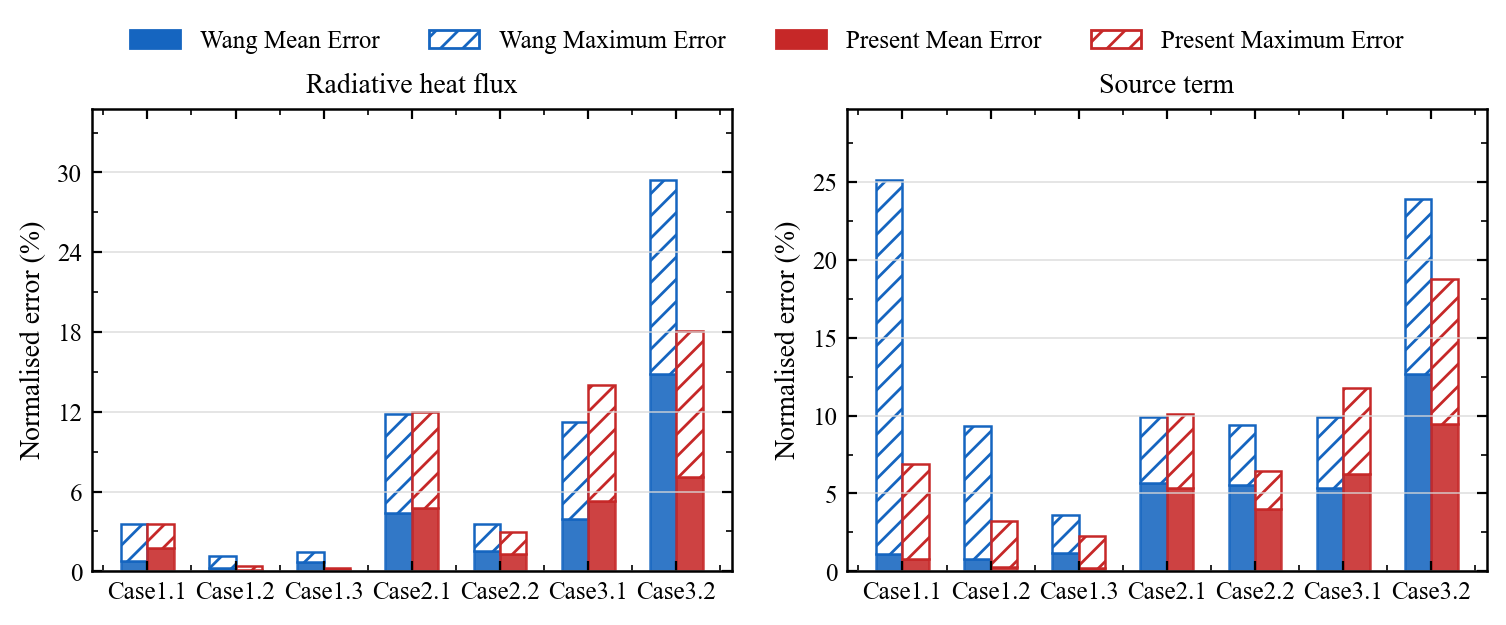

In [21]:
# Editable parameters for this figure
figsize = (9, 3)
legend_bbox = (0.5, 1.05)
panel_labels = PANEL_LABELS
y_padding_factor = 1.18
width = 0.3
save_stem = "case_error_summary"

summary_rows = []
for index, path in enumerate(CASE_FILES, start=1):
    result = get_case_result(path.stem, index)

    # 处理case name，只保留第一个下划线之前的部分
    case_name = path.stem
    simple_name = case_name.split('_')[0]
    config_label = simple_name
    
    summary_rows.append({
        "config_label": config_label,
        "wang_mae_q": float(np.mean(np.abs(result["delta_q_wang"]))),
        "wang_maxae_q": float(np.max(np.abs(result["delta_q_wang"]))),
        "wang_mae_st": float(np.mean(np.abs(result["delta_st_wang"]))),
        "wang_maxae_st": float(np.max(np.abs(result["delta_st_wang"]))),
        "rsm_mae_q": float(np.mean(np.abs(result["delta_q_rsm"]))),
        "rsm_maxae_q": float(np.max(np.abs(result["delta_q_rsm"]))),
        "rsm_mae_st": float(np.mean(np.abs(result["delta_st_rsm"]))),
        "rsm_maxae_st": float(np.max(np.abs(result["delta_st_rsm"]))),
    })

case_labels = [row["config_label"] for row in summary_rows]
x = np.arange(len(summary_rows))

fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"wspace": 0.18})
plot_specs = [
    (axes[0], "rsm_mae_q", "rsm_maxae_q", "wang_mae_q", "wang_maxae_q", "Radiative heat flux", "(a)"),
    (axes[1], "rsm_mae_st", "rsm_maxae_st", "wang_mae_st", "wang_maxae_st", "Source term", "(b)"),
]

for ax, rsm_mae_key, rsm_max_key, wang_mae_key, wang_max_key, title, panel_label in plot_specs:
    wang_mae = np.asarray([row[wang_mae_key] for row in summary_rows], dtype=float)
    wang_cap = np.asarray([row[wang_max_key] for row in summary_rows], dtype=float)
    rsm_mae = np.asarray([row[rsm_mae_key] for row in summary_rows], dtype=float)
    rsm_cap = np.asarray([row[rsm_max_key] for row in summary_rows], dtype=float)

    ax.bar(
        x - width / 2, wang_mae, width,
        color=gvp.COLORS["wang"], alpha=0.88,
        edgecolor=gvp.COLORS["wang"], linewidth=0.9,
    )
    ax.bar(
        x - width / 2, np.maximum(0.0, wang_cap - wang_mae), width,
        bottom=wang_mae,
        facecolor="white", edgecolor=gvp.COLORS["wang"],
        hatch="///", linewidth=0.9,
    )
    ax.bar(
        x + width / 2, rsm_mae, width,
        color=gvp.COLORS["present"], alpha=0.88,
        edgecolor=gvp.COLORS["present"], linewidth=0.9,
    )
    ax.bar(
        x + width / 2, np.maximum(0.0, rsm_cap - rsm_mae), width,
        bottom=rsm_mae,
        facecolor="white", edgecolor=gvp.COLORS["present"],
        hatch="///", linewidth=0.9,
    )

    # for x_coord, total in zip(x - width / 2, wang_cap):
    #     ax.text(x_coord, total + 0.6, "{:.1f}".format(total), ha="center", va="bottom", fontsize=8.2, color=gvp.COLORS["wang"])
    # for x_coord, total in zip(x + width / 2, rsm_cap):
    #     ax.text(x_coord, total + 0.6, "{:.1f}".format(total), ha="center", va="bottom", fontsize=8.2, color=gvp.COLORS["present"])

    gvp.style_axes(ax, grid_axis="y")
    ax.set_xticks(x)
    ax.set_xticklabels(case_labels)
    # ax.set_xlabel("Case")
    ax.set_title(title)
    ax.set_ylabel("Normalised error (%)")
    ax.set_ylim(0.0, max(float(np.max(wang_cap)), float(np.max(rsm_cap))) * y_padding_factor)
    gvp.add_panel_label(ax, panel_label, panel_labels)

legend_handles = [
    Patch(facecolor=gvp.COLORS["wang"], edgecolor=gvp.COLORS["wang"], label="Wang Mean Error"),
    Patch(facecolor="white", edgecolor=gvp.COLORS["wang"], hatch="///", label="Wang Maximum Error"),
    Patch(facecolor=gvp.COLORS["present"], edgecolor=gvp.COLORS["present"], label="Present Mean Error"),
    Patch(facecolor="white", edgecolor=gvp.COLORS["present"], hatch="///", label="Present Maximum Error"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=legend_bbox, ncol=4)

maybe_save(fig, save_stem if SAVE_FIGURES else None)
